# <center> Сегментация клиентов онлайн магазина подарков

## Постановка задачи


<center> <img src=https://salesupnow.ru/storage/app/media/pipeople.png align="right" width="300"/> </center>

Маркетинг — неотъемлемая часть любого бизнеса. Для повышения прибыли компании важно понимать своего клиента, его пожелания и предпочтения. С появлением электронной коммерции, или онлайн-продаж, стало намного проще собирать данные о клиентах, анализировать их, находить закономерности и реализовывать маркетинговые кампании.

Большинство интернет-магазинов используют инструменты веб-аналитики, чтобы отслеживать просмотры страниц, количество и поведение посетителей и коэффициент отказов. Но отчёта из Google Analytics или аналогичной системы может быть недостаточно для полного понимания того, как клиенты взаимодействуют с сайтом. Компаниям важно иметь возможность быстро и точно реагировать на перемены в поведении клиентов, создавая инструменты, которые обнаруживают эти изменения практически в режиме реального времени.

Машинное обучение помогает поисковой системе анализировать огромное количество данных о посетителях платформы, узнавать модели поведения профессиональных покупателей, определять категорию клиентов (например, лояльные/перспективные/новички/спящие/ушедшие) и выбирать правильную стратегию взаимодействия с ними.

Стоит также отметить, что компании, использующие машинное обучение на своих платформах электронной коммерции, могут постоянно повышать эффективность бизнес-процессов: настраивать товарную выборку персонально для каждого покупателя и предлагать выгодную цену в соответствии с бюджетом клиента и т. д. Эта задача относится к категории построения рекомендательных систем, речь о которых пойдёт в следующем разделе нашего курса.

> Как правило, наборы данных для электронной коммерции являются частной собственностью и, следовательно, их трудно найти среди общедоступных данных. Однако [The UCI Machine Learning Repository](http://archive.ics.uci.edu/ml/index.php)  создал набор данных, содержащий фактические транзакции за 2010 и 2011 годы. С ним нам как раз и предлагается поработать в этом кейсе. 

> В нашем распоряжении будет набор данных, который содержит все транзакции, произошедшие в период с 01/12/2010 по 09/12/2011 для базирующейся в Великобритании компании, занимающейся онлайн-розничной торговлей. Компания в основном продает уникальные подарки на все случаи жизни. Многие клиенты компании являются оптовиками.


**Бизнес-задача:** произвести сегментацию существующих клиентов, проинтерпретировать эти сегменты и определить стратегию взаимодействия с ними.

**Техническая задача для вас как для специалиста в Data Science:** построить модель кластеризации клиентов на основе их покупательской способности, частоты заказов и срока давности последней покупки, определить профиль каждого из кластеров.

**Основные цели проекта:**
1. Произвести предобработку исходного набора данных о транзакциях.
2. Провести разведывательный анализ данных и выявить основные закономерности.
3. Сформировать набор данных о характеристиках каждого из уникальных клиентов.
4. Построить несколько моделей машинного обучения, решающих задачу кластеризации клиентов, определить количество кластеров и проинтерпретировать их.
5. Спроектировать процесс предсказания категории интересов клиента и протестировать модель на новых клиентах.

## Данные и их описание

Данные представляют собой таблицу в формате CSV, в каждой строке которой содержится информация об уникальной транзакции.

Признаки, описывающие каждую транзакцию:

* InvoiceNo — номер счёта-фактуры (уникальный номинальный шестизначный номер, присваиваемый каждой транзакции; буква "C" в начале кода указывает на отмену транзакции);
* StockCode — код товара (уникальное пятизначное целое число, присваиваемое каждому отдельному товару);
* Description — название товара;
* Quantity — количество каждого товара за транзакцию;
* InvoiceDate — дата и время выставления счёта/проведения транзакции;
* UnitPrice — цена за единицу товара в фунтах стерлингов;
* CustomerID — идентификатор клиента (уникальный пятизначный номер, однозначно присваиваемый каждому клиенту);
* Country — название страны, в которой проживает клиент.

Импорт базовых библиотек:

In [1]:
#Базовые библиотеки
import pandas as pd
import numpy as np

#Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

#Машинное обучение
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

#Статистика
import scipy.stats as stats

#Настройки
import warnings
from IPython.display import display, HTML
warnings.filterwarnings("ignore")

plt.rcParams["patch.force_edgecolor"] = True

## 1. Знакомство со структурой данных

Первым делом необходимо понять, с какими данными предстоит работать, и произвести базовую предобработку данных — перевести признаки в необходимые для дальнейшей работы форматы.

Познакомимся с исходными данными поближе:

* Проведем статистический анализ исходных данных, посмотрев на основные диапазоны исходных признаков.
* Узнаем сколько уникальных клиентов совершали транзакции в указанный период.
* Узнаем, из каких стран совершались транзакции.
* Исследуем данные на наличие пропусков и дубликатов.
* Переведем столбцы в корректные форматы (например, даты в формат datetime).

In [ ]:
# Чтение данных
data = pd.read_csv(
    "data/pj6_data.zip", 
    encoding="ISO-8859-1", 
    dtype={'CustomerID': str,'InvoiceNo': str}
)
print('Размерность данных: {}'.format(data.shape))
print('Пример данных:')
display(data.head(3))

# Структура данных
data.info()

Размерность данных: (541909, 8)
Пример данных:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


Подавляющее большинство исходных данных представлено в формате object. Признак InvoiceDate преобразуем в формат datetime для работы с временными рядами. Идентификаторы клиентов (CustomerID) состоят из цифр, однако для экономии памяти без потери данных мы преобразуем их в тип category. Для остальных признаков преобразований пока не требуется. В признаках Description и CustomerID имеются пропуски.

In [3]:
# Преобразование форматов
data['CustomerID'] = data['CustomerID'].astype('category')
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

In [4]:
# Посмотрим основную статистическую информацию и проверим данные на наличие дубликатов.

# Статистическая информация по числовым не порядковым признакам
print("Статистика продаж (Quantity и UnitPrice):")
display(data[['Quantity', 'UnitPrice']].describe().round(2))

# Важная статистическая информация по категориальным признакам
print("\nУникальность данных:")
print(f"- Уникальных заказов: {data['InvoiceNo'].nunique()}")
print(f"- Уникальных товаров: {data['StockCode'].nunique()}")
print(f"- Уникальных клиентов: {data['CustomerID'].nunique()}")
top_countries = data['Country'].value_counts().head(5).index.tolist()
print(f"- Уникальных стран: {data['Country'].nunique()} (топ-5: {', '.join(top_countries)})")

# Дополнительная информация
print("\nВременной интервал:")
print(f"- С {data['InvoiceDate'].dt.date.min()} по {data['InvoiceDate'].dt.date.max()}")
print("\nАномалии в ценах:")
print(f"- Товары с нулевой ценой: {(data['UnitPrice'] == 0).sum()}")
print(f"- Товары с отрицательной ценой: {(data['UnitPrice'] < 0).sum()}")
print("\nТранзакции:")
print(f"- Возвраты (отрицательное количество): {(data['Quantity'] < 0).sum()}")
print(f"- Покупки (положительное количество): {(data['Quantity'] > 0).sum()}")
print("\nКачество данных:")
print(f"- Полных дубликатов строк: {data.duplicated().sum()}")

Статистика продаж (Quantity и UnitPrice):


,Quantity,UnitPrice
count,541909.00,541909.00
mean,9.55,4.61
std,218.08,96.76
min,-80995.00,-11062.06
25%,1.00,1.25
50%,3.00,2.08
75%,10.00,4.13
max,80995.00,38970.00



Уникальность данных:
- Уникальных заказов: 25900
- Уникальных товаров: 4070
- Уникальных клиентов: 4372
- Уникальных стран: 38 (топ-5: United Kingdom, Germany, France, EIRE, Spain)

Временной интервал:
- С 2010-12-01 по 2011-12-09

Аномалии в ценах:
- Товары с нулевой ценой: 2515
- Товары с отрицательной ценой: 2

Транзакции:
- Возвраты (отрицательное количество): 10624
- Покупки (положительное количество): 531285

Качество данных:
- Полных дубликатов строк: 5268


**Вывод:** 
- Временной охват:

    - Данные содержат информацию о транзакциях за период чуть более одного года (с 1 декабря 2010 по 9 декабря 2011 года).

- Качество данных и аномалии:

    - Выявлены критические аномалии в стоимости: 2 515 товаров с нулевой ценой и 2 транзакции с отрицательной ценой.
    - Обнаружено 5 268 полных дубликатов строк, а также масштабный пропуск идентификаторов клиентов (около 25% записей в CustomerID).
    - В данных присутствуют возвраты — 10 624 строк с отрицательным количеством Quantity, которые требуют особой обработки.

- Преобразование форматов: 
    - Выполнено приведение признака InvoiceDate к формату datetime.
    - Идентификатор CustomerID переведен в тип category для оптимизации оперативной памяти с сохранением строковой структуры ID.
    
На следующем этапе все обнаруженные аномалии, дубликаты и пропуски в ID будут очищены, чтобы исключить искажение результатов кластеризации.

## 2. Преобразование, очистка и анализ данных

### 2.1. Преобразование и очистка данных о транзакциях

#### 2.1.1 Пропуски

Как было выше указано в данных имеются пропуски, посмотрим на их количество.

In [ ]:
# Таблица пропусков
missing_counts = data.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_df = pd.DataFrame({
    'Столбец': missing_counts.index,
    'Количество пропусков': missing_counts.values,
    'Доля (%)': (missing_counts.values / len(data) * 100).round(2)
})
print("Пропуски в данных:")
display(missing_df)

Пропуски в данных:


,Столбец,Количество пропусков,Доля (%)
0,Description,1454,0.27
1,CustomerID,135080,24.93


CustomerID — это ключевой признак для анализа клиентов. Без идентификатора клиента невозможно:
- Отследить поведение конкретного клиента
- Посчитать возвраты
- Сделать выводы о покупательской способности

Такие строки бесполезны для дальнейшего анализа, поэтому просто удалим их из данных.

In [ ]:
# Удаляем пропуски в 'CustomerID'
data = data.dropna(subset=['CustomerID']).copy()
# Проверяем 'Description'
desc_missing = data['Description'].isnull().sum()
print(f"Пропуски в Description после удаления строк без CustomerID: {desc_missing}")

Пропуски в Description после удаления строк без CustomerID: 0


**Вывод**: После удаления строк с пропущенными CustomerID, пропуски в столбце Description также сократились до 0. Это свидетельствует о том, что текстовое описание отсутствовало исключительно в транзакциях, где не был указан идентификатор клиента. Датасет полностью очищен от пропусков.

#### 2.1.2. Дубликаты

В данных обнаружены дубликаты, удалим их.

In [ ]:
print(f"Удалено дубликатов: {data.duplicated().sum()}")
data = data.drop_duplicates().copy()
print(f'Размерность данных: {data.shape}')

Удалено дубликатов: 5225
Размерность данных: (401604, 8)


**Вывод**: На этапе первичного анализа было выявлено 5 268 дубликатов. После очистки строк без CustomerID количество полных дубликатов внутри целевой выборки составило 5 225. Данные записи были успешно удалены, чтобы избежать искусственного завышения частоты и объемов покупок.

#### 2.1.3. Транзакции с отрицательным количеством товара

Для корректного учета покупательской способности необходимо сопоставить возвраты с исходными покупками. Сначала оценим структуру корзин (количества уникальных товаров в одном чеке) для каждого клиента:

In [ ]:
# Группируем данные
temp = data.groupby(
    by=["CustomerID", "InvoiceNo"], as_index=False, observed=True
)["InvoiceDate"].count()
nb_products_per_basket = temp.rename(columns={'InvoiceDate': 'Number of products'})
nb_products_per_basket.head()

,CustomerID,InvoiceNo,Number of products
0,12346,541431,1
1,12346,C541433,1
2,12347,537626,31
3,12347,542237,29
4,12347,549222,24


In [9]:
# Заказы с 'C' в начале - это возвраты
returns_by_invoice = data[data['InvoiceNo'].str.startswith('C')]['InvoiceNo'].nunique()
total_invoices = data['InvoiceNo'].nunique()
print(f"Всего уникальных заказов: {total_invoices}")
print(f"Из них заказов-возвратов (с буквой C): {returns_by_invoice}")
print(f"Доля возвратов: {returns_by_invoice / total_invoices * 100:.2f}%")

Всего уникальных заказов: 22190
Из них заказов-возвратов (с буквой C): 3654
Доля возвратов: 16.47%


**Важное наблюдение**: Анализ уникальных номеров счетов (InvoiceNo) показал, что из 22 190 уникальных заказов 3 654 являются возвратами (содержат литеру «C»). Таким образом, 16.47% от всех оформленных заказов содержат возвраты. Расчет доли возвратов по общему числу строк (товаров) дал бы ложное представление (~2%), так как один инвойс на возврат часто включает в себя сразу несколько позиций из исходного чека.

Теперь перейдём к созданию признака QuantityCanceled с помощью вспомогательной функции. Этот признак будет указывать на количество отменённого впоследствии товара для каждой транзакции, на которую найдётся противоположная ей транзакция с возвратом. Для транзакций, для которых не было возвратов, признак будет равен 0. Для транзакций, для которых указано отрицательное количество товара, но в данных отсутствует контрагент, признак будет пустым.

In [10]:
def get_quantity_canceled(data):
    """Функция для создания признака количества отменённых заказов. 
    Функция принимает на вход таблицу и возвращает столбец, в котором указано количество отменённого впоследствии товара для каждой транзакции.
    Если транзакция с отрицательным количеством товара не имеет контрагента, данный признак помечается как NaN.

    Args:
        data (DataFrame): таблица с транзакциями

    Returns:
        Series: столбец с количеством отменённого товара
    """
    # Инициализируем нулями Series той же длины, что и столбцы таблицы.
    quantity_canceled = pd.Series(np.zeros(data.shape[0]), index=data.index)    
    negative_quantity = data[(data['Quantity'] < 0)].copy()
    for index, col in negative_quantity.iterrows():
        # Создаём DataFrame из всех контрагентов
        df_test = data[(data['CustomerID'] == col['CustomerID']) &
                       (data['StockCode'] == col['StockCode']) & 
                       (data['InvoiceDate'] < col['InvoiceDate']) & 
                       (data['Quantity'] > 0)].copy()
        # Транзация-возврат не имеет контрагента — ничего не делаем
        if (df_test.shape[0] == 0): 
            # Помечаем столбец как пропуск
            quantity_canceled.loc[index] = np.nan
        # Транзакция-возврат имеет ровно одного контрагента
        # Добавляем количество отменённого товара в столбец QuantityCanceled 
        elif (df_test.shape[0] == 1): 
            index_order = df_test.index[0]
            quantity_canceled.loc[index_order] = -col['Quantity']       
        # Транзакция-возврат имеет несколько контрагентов
        # Задаём количество отменённого товара в столбец QuantityCanceled для той транзакции на покупку,
        # в которой количество товара больше количества товаров в транзакции-возврате.
        elif (df_test.shape[0] > 1): 
            df_test.sort_index(axis=0, ascending=False, inplace=True)        
            for ind, val in df_test.iterrows():
                if val['Quantity'] < -col['Quantity']: 
                    continue
                quantity_canceled.loc[ind] = -col['Quantity']
                break    
    return quantity_canceled

data['QuantityCanceled'] = get_quantity_canceled(data)

Узнаем, сколько транзакций в данных не имеют контрагентов, и, если их количество невелико, удалим их из данных.
Кроме того, так как мы уже разобрались с возвратами, удалим транзакции с отрицательным количеством товара — они нам больше не нужны.

In [ ]:
# Проверяем количество возвратов 
quantity_canceled_count = (data['QuantityCanceled'].isna() & (data['Quantity'] < 0)).sum()
print(f"Возвратов без контрагента: {quantity_canceled_count}")
share_of_total = quantity_canceled_count / len(data) * 100
print(f"Доля от всех данных: {share_of_total:.2f}%")

Возвратов без контрагента: 1303
Доля от всех данных: 0.32%


In [12]:
# Данных без контрагента действительно не много, поэтому удаляем их
data = data.dropna(subset=['QuantityCanceled']).copy()

# Удаляем все возвраты
data = data[data['Quantity'] > 0].copy()

# Проверим текущую размерность данных
print(f'Размерность данных: {data.shape}')

Размерность данных: (392732, 9)


In [ ]:
# Можно поменять тип данных так как nan удалены на int
# Посмотрим на максимальное значение
max_canceled = data['QuantityCanceled'].max()
print(f"Максимум: {max_canceled}")

Максимум: 80995.0


In [ ]:
# Меняю на int32
data['QuantityCanceled'] = data['QuantityCanceled'].astype('int32')

**Вывод**:
- *Корректировка возвратов*: С помощью алгоритма сопоставления транзакций был создан признак QuantityCanceled. Он позволил перенести информацию о возвращенных товарах напрямую в строки соответствующих исходных покупок.
- *Удаление аномальных возвратов*: Было обнаружено 1 303 транзакции возврата (0.32% от общего объема данных), для которых не удалось найти исходный чек покупки (возвраты без контрагента). Ввиду их крайне малой доли и невозможности корректной интерпретации, данные записи были удалены без риска искажения итоговой выборки.
- *Очистка датасета*: Из датасета успешно удалены все строки с отрицательным количеством товара (Quantity < 0), так как факт отмены теперь зафиксирован в признаке QuantityCanceled. Итоговая размерность таблицы транзакций составила 392 732 строки. Признак QuantityCanceled успешно приведен к целочисленному типу int32, так как в данных больше нет пропусков (NaN).

#### 2.1.4. Специализированные транзакции

Следующая задача — обработать специальные виды транзакций, которые обозначаются латинскими буквами.

В данных присутствует шесть специальных видов транзакций. Найдём с помощью регулярных выражений коды товаров (StockCode), которые начинаются с латинских букв (при этом коды могут содержать цифры).

In [15]:
# Поиск специальных кодов товаров
special_codes = data[data['StockCode'].str.match(r'^[a-zA-Z]+', na=False)]
print(f"Найдено специальных кодов: {special_codes['StockCode'].nunique()}")

Найдено специальных кодов: 6


Чтобы понять, что означают эти коды, можно заглянуть в столбец с описанием (Description).

In [16]:
print("Специальные коды и их описание:")
display(special_codes[['StockCode', 'Description']].drop_duplicates())

Специальные коды и их описание:


,StockCode,Description
45,POST,POSTAGE
1423,C2,CARRIAGE
2239,M,Manual
4406,BANK CHARGES,Bank Charges
157195,PADS,PADS TO MATCH ALL CUSHIONS
317507,DOT,DOTCOM POSTAGE


- POST — почтовые расходы
- C2 — расходы на транспортировку (carriage)
- M — ручные операции (manual)
- BANK CHARGES — банковские расходы
- PADS — сопутствующие товары
- DOT — почтовые расходы для онлайн заказов

Специальные операции не характеризуют покупательскую способность клиентов, так как не относятся напрямую к их покупкам. Такие записи нам не нужны, поэтому удалим все специальные транзакции из таблицы.

In [17]:
# Удаляем строки со специальными кодами товаров
data = data[~data['StockCode'].str.match(r'^[a-zA-Z]+', na=False)].copy()

print(f"Размер данных после удаления специальных транзакций: {data.shape}")

Размер данных после удаления специальных транзакций: (391183, 9)


**Вывод**:
- *Идентификация нетоварных операций*: С помощью регулярных выражений в датасете было обнаружено 6 типов специальных сервисных кодов (POST, C2, M, BANK CHARGES, PADS, DOT). Они относятся к сопутствующим расходам: доставке, ручным корректировкам и банковским комиссиям.
- *Обоснование удаления*: Данные транзакции не отражают реальный покупательский интерес клиентов к товарному ассортименту и способны искусственно завысить средний чек (Monetary) и частоту покупок (Frequency), искажая профили кластеров.
- *Результат очистки*: После удаления всех сервисных записей размерность датасета снизилась до 391 183 строк.

#### 2.1.5. Транзакции с товарами без стоимости

При просмотре описательных статистик ранее мы заметили, что на некоторые товары установлена нулевая или отрицательная цена. Такие транзакции не отражают реальную продажу, но могут исказить расчёты среднего чека и выручки, поэтому удалим их.

In [18]:
# Проверяем транзакции с некорректной ценой
zero_price_count = (data['UnitPrice'] == 0).sum()
negative_price_count = (data['UnitPrice'] < 0).sum()

print(f"Транзакций с нулевой ценой: {zero_price_count} ({zero_price_count / len(data) * 100:.2f}%)")
print(f"Транзакций с отрицательной ценой: {negative_price_count} ({negative_price_count / len(data) * 100:.2f}%)")

# Удаляем транзакции с некорректной ценой (<= 0)
data = data[data['UnitPrice'] > 0].copy()

print(f"Размер данных после удаления: {data.shape}")

Транзакций с нулевой ценой: 33 (0.01%)
Транзакций с отрицательной ценой: 0 (0.00%)
Размер данных после удаления: (391150, 9)


**Вывод**:
- *Анализ ценовых аномалий*: После удаления нетоварных операций количество строк с нулевой ценой снизилось до 33 (всего 0.01% от выборки), а транзакции с отрицательной стоимостью полностью отсутствуют.
- *Обоснование удаления*: Нулевая стоимость товаров обычно указывает на маркетинговые подарки, технические сбои или складские списания. Так как эти операции не отражают реальную покупательскую способность и коммерческое поведение клиентов, они исключены из анализа.
- *Итог этапа очистки транзакций*: Финальный объем очищенного датасета составил 391 150 транзакций.

#### 2.1.6. Общая стоимость товаров в транзакции

Добавим в датасет общую цену заказа (TotalPrice). Она рассчитывается как:
 
 **общая цена = цена за единицу товара * (количество товаров в заказе - количество возвращённых товаров).**

Этот признак впоследствии поможет нам рассчитать покупательскую способность каждого из клиентов.

In [19]:
# Рассчитываем общую стоимость с учётом возвратов
data['TotalPrice'] = data['UnitPrice'] * (data['Quantity'] - data['QuantityCanceled'])

# Проверим результат
print(f"Средняя стоимость заказа: {data['TotalPrice'].mean():.2f} фунтов")
print(f"Медианная стоимость заказа: {data['TotalPrice'].median():.2f} фунтов")
print(f"Общая выручка с учётом возвратов: {data['TotalPrice'].sum():.2f} фунтов")

# Проверим строки, где TotalPrice отрицательный (чистые возвраты)
negative_total = (data['TotalPrice'] < 0).sum()
print(f"Строк с отрицательной TotalPrice: {negative_total}")
print(f"Доля: {negative_total / len(data) * 100:.4f}%")

Средняя стоимость заказа: 21.13 фунтов
Медианная стоимость заказа: 11.70 фунтов
Общая выручка с учётом возвратов: 8263592.99 фунтов
Строк с отрицательной TotalPrice: 36
Доля: 0.0092%


Так как функция для создания признака количества отменённых заказов слегка несовершенна, у нас остался необработанным момент, когда у клиента объем возвратов превысил объем покупок. У данных клиентов соответственно общая стоимость товаров в транзакции отрицательна. Так как таких данных всего 36 строк, и так как они отрицательно сказываются на дальнейшем анализе, было принято решение их удалить:

In [20]:
data = data[data['TotalPrice'] > 0].copy()
print(f"Размер после удаления: {data.shape}")

Размер после удаления: (388571, 10)


Помимо рекомендованных преобразований, мы также можем применить собственные при необходимости. В данном случае выполнены все основные этапы очистки:
- Удалены строки без идентификатора клиента (CustomerID)
- Удалены дубликаты
- Создан признак QuantityCanceled (количество возвращённого товара)
- Удалены возвраты (строки с отрицательным Quantity)
- Удалены специальные транзакции (коды товаров, начинающиеся с букв)
- Удалены транзакции с нулевой и отрицательной ценой
- Добавлен признак общей стоимости заказа (TotalPrice)
- Удалены отрицательные значения общей стоимости заказа (то есть строки где возвращенного товара больше чем купленного за рассматриваемый период)

После завершения предобработки сохраним результат очищения данных в отдельный файл, чтобы впоследствии не пришлось повторять эти действия.

In [21]:
# Финальная проверка размерности и пропусков
print("Финальная проверка данных:")
print(f"Размерность данных: {data.shape}")
print(f"Количество пропусков: {data.isnull().sum().sum()}")
print(f"Типы данных:\n{data.dtypes}")

# Сохраняем очищенные данные
data.to_csv("data/pj6_data_cleaned.csv", index=False, encoding="utf-8")
print("\nДанные сохранены в файл: data/pj6_data_cleaned.csv")

Финальная проверка данных:
Размерность данных: (388571, 10)
Количество пропусков: 0
Типы данных:
InvoiceNo                   object
StockCode                   object
Description                 object
Quantity                     int64
InvoiceDate         datetime64[ns]
UnitPrice                  float64
CustomerID                category
Country                     object
QuantityCanceled             int32
TotalPrice                 float64
dtype: object

Данные сохранены в файл: data/pj6_data_cleaned.csv


**Итог**: Данные очищены и готовы к дальнейшему анализу и сегментации клиентов.

**Вывод**:
- *Коррекция аномалий формулы*: Исключение 36 транзакций с отрицательным значением TotalPrice обосновано бизнес-логикой. Данная аномалия возникла из-за редких случаев, когда объем возвратов товара клиентом за текущий год превысил объем его покупок этого же товара в рамках рассматриваемого временного периода.
- *Итоги предобработки транзакций*: На этапе очистки объем исходного датасета сократился с 541 909 до 388 571 строк (сохранено около 72% данных). В данных полностью отсутствуют пропуски, дубликаты, нетоварные операции и ценовые аномалии.
- *Готовность к анализу*: Очищенный массив данных успешно сохранен в файл pj6_data_cleaned.csv. Данные полностью готовы к разведывательному анализу.

In [22]:
# data = pd.read_csv("data/pj6_data_cleaned.csv")
# data['CustomerID'] = data['CustomerID'].astype('category')
# data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

### 2.2. Разведывательный анализ

После предобработки исходных данных проведем разведывательный анализ и исследуем транзакции, ответив на следующие вопросы:

1. Клиенты из каких стран покупают больше и чаще?
2. Какие страны приносят наибольшую сезонную выручку?
3. Присутствует ли в продажах сезонность (когда покупают чаще)?
4. Сгруппируйте данные по датам и часам совершения транзакции и найдите количество заказов на каждый день-час. Затем найдите среднее количество ежедневно поступающих заказов в каждый из часов.
5. Каково распределение среднего количества ежедневно поступающих заказов по времени суток (часу совершения транзакции)?

Для начала определим основные вспомогательные функции

#### 2.2.1. Подготовка

Для начала зададим некоторые функции: функция проверки на нормальность, проверки равенства дисперсий, и отклонении или принятии нулевой гипотезы, функция помогающая выбрать необходимый тест. Внутри функции пропишем уровень значимости $\alpha = 0,05$.

In [ ]:
# Определяю необходимые мне функции
def get_test_recommendation(groups, is_dependent=False, alpha=0.05):
    """Функция для анализа характеристик данных.
    Помогает определить нормальность, равенство дисперсий
    и выбрать подходящий статистический тест.

    Args:
        groups (list of array-like): список выборок [group_1, group_2]
        is_dependent (bool): True если группы зависимые, False если нет. По умолчанию False
        alpha (float): уровень значимости, по умолчанию 0.05

    Returns:
        str: название рекомендуемой функции для проведения теста
    """
    n_groups = len(groups)
    if n_groups < 1:
        print("Ошибка: Передан пустой список групп.")
        return "error"

    # Проверка нормальности для всех групп
    norm_flags = []
    for i, g in enumerate(groups):
        _, p_norm = stats.shapiro(g)
        is_g_norm = p_norm > alpha
        norm_flags.append(is_g_norm)
        status = "Нормальное" if is_g_norm else "Отлично от нормального"
        print(f"Группа {i+1}: p-value (Shapiro) = {p_norm:.3f} -> {status}")

    # Общая нормальность (True, только если ВСЕ группы нормальны)
    is_normal = all(norm_flags)

    # Проверка дисперсии
    equal_var = True
    if n_groups >= 2 and not is_dependent:
        _, p_var = stats.levene(*groups)
        equal_var = p_var > alpha
        status_var = "одинаковы" if equal_var else "не одинаковы"
        print(f"Проверка дисперсий: p-value (Levene) = {p_var:.3f} -> "
              f"Дисперсии {status_var}")
    else:
        print("Проверка дисперсий: Не требуется.")

    # Логика выбора теста
    if n_groups == 1:
        if is_normal:
            print(
                "Рекомендация: так как группа одна и распределение "
                "нормальное, применяется одновыборочный t-критерий: "
                "scipy.stats.ttest_1samp."
            )
        else:
            print(
                "Рекомендация: так как группа одна, а распределение "
                "ненормальное, применяется критерий знаков: "
                "statsmodels.stats.descriptivestats.sign_test"
            )

    elif n_groups == 2:
        if is_dependent:
            if is_normal:
                print(
                    "Рекомендация: для двух зависимых групп с нормальным "
                    "распределением применяется парный t-критерий: "
                    "scipy.stats.ttest_rel"
                )
            else:
                print(
                    "Рекомендация: для двух зависимых групп с ненормальным "
                    "распределением применяется критерий Уилкоксона: "
                    "scipy.stats.wilcoxon"
                )
        else:
            if is_normal:
                if equal_var:
                    print(
                        "Рекомендация: для двух независимых групп с "
                        "нормальным распределением и равными дисперсиями "
                        "применяется t-критерий Стьюдента: "
                        "scipy.stats.ttest_ind(..., equal_var=True)"
                    )
                else:
                    print(
                        "Рекомендация: для двух независимых групп с "
                        "нормальным распределением, но разными дисперсиями "
                        "применяется t-критерий Уэлча: "
                        "scipy.stats.ttest_ind(..., equal_var=False)"
                    )
            else:
                print(
                    "Рекомендация: для двух независимых групп с "
                    "ненормальным распределением применяется U-критерий "
                    "Манна-Уитни: scipy.stats.mannwhitneyu"
                )

    else:  # 3+ групп
        if is_dependent:
            if is_normal:
                print(
                    "Рекомендация: для трех и более зависимых групп с "
                    "нормальным распределением применяется ANOVA с "
                    "повторными измерениями: "
                    "statsmodels.stats.anova.AnovaRM"
                )
            else:
                print(
                    "Рекомендация: для трех и более зависимых групп с "
                    "ненормальным распределением применяется критерий "
                    "Фридмана: scipy.stats.friedmanchisquare"
                )
        else:
            if is_normal:
                if equal_var:
                    print(
                        "Рекомендация: для трех и более независимых групп "
                        "с нормальным распределением и равными дисперсиями "
                        "применяется классический ANOVA: scipy.stats.f_oneway"
                    )
                else:
                    print(
                        "Рекомендация: для трех и более независимых групп "
                        "с нормальным распределением, но разными "
                        "дисперсиями применяется критерий Уэлча ANOVA: "
                        "statsmodels.stats.oneway.anova_oneway"
                    )
            else:
                print(
                    "Рекомендация: для трех и более независимых групп "
                    "с ненормальным распределением применяется критерий "
                    "Краскела-Уоллиса: scipy.stats.kruskal"
                )


def get_gip(p_value, alpha=0.05):
    """Функция, помогающая принять или отвергнуть нулевую гипотезу.
    
    Args:
        p_value (float): p-value статистического теста
        alpha (float): уровень значимости, по умолчанию 0.05
        
    Returns:
        str: подсказка о результате проверки гипотезы
    """
    print(f'p-value = {p_value:.3f}')
    
    if p_value <= alpha:
        print(f'p-значение меньше, чем заданный уровень значимости {alpha}. '
              'Отвергаем нулевую гипотезу.')
    else:
        print(f'p-значение больше, чем заданный уровень значимости {alpha}. '
              'У нас нет оснований отвергнуть нулевую гипотезу.')

Таблица напоминание:

|**Нулевая гипотеза**|**Альтернативная гипотеза**|<center> **Тип**|
|--|--|--|
|$H_0 : μ_1 = μ_2$ |$H_1: \mu_1 \ne \mu_2$<br>|двухсторонняя, `alternative='two-sided'`|
|$H_0: \mu_1 \geq \mu_2$|$H_1: \mu_1 < \mu_2$|левосторонняя, `alternative='less'`|
|$H_0: \mu_1 \leq \mu_2$|$H_1: \mu_1 > \mu_2$|правосторонняя, `alternative='greater'`|

#### 2.2.2. Анализ по времени и датам

In [24]:
# Создаём признаки даты и времени
data["Month"] = data["InvoiceDate"].dt.month
data["Day"] = data["InvoiceDate"].dt.day
data["Hour"] = data["InvoiceDate"].dt.hour
data["Weekday"] = data["InvoiceDate"].dt.weekday

# Признак сезона с правильной календарной сортировкой
seasons_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
}
data['Season'] = data['Month'].map(seasons_map)
season_type = pd.CategoricalDtype(
    categories=["Winter", "Spring", "Summer", "Autumn"], 
    ordered=True
)
data['Season'] = data['Season'].astype(season_type)

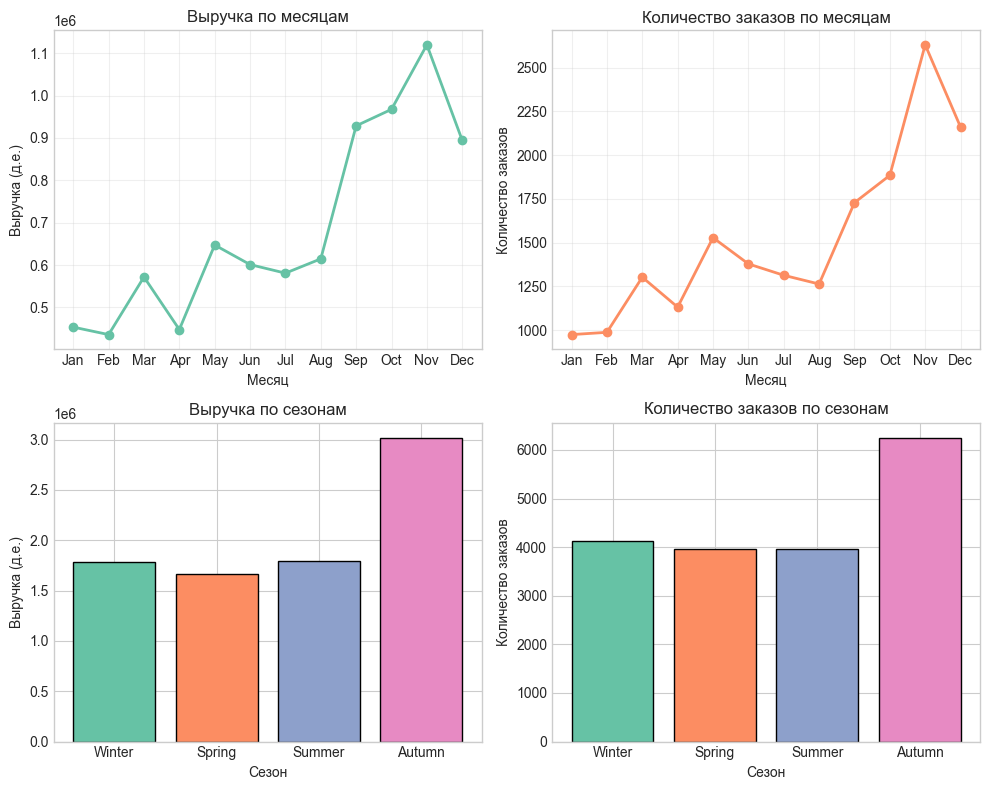

In [25]:
# Анализ сезонности
monthly_revenue = data.groupby('Month')['TotalPrice'].sum()
monthly_orders = data.groupby('Month')['InvoiceNo'].nunique()
seasonal_revenue = data.groupby('Season')['TotalPrice'].sum()
seasonal_orders = data.groupby('Season')['InvoiceNo'].nunique()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
colors = sns.color_palette("Set2", 4)
name_month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Выручка по месяцам
axes[0, 0].plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, color=colors[0])
axes[0, 0].set_title('Выручка по месяцам', fontsize=12)
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Выручка (д.е.)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(name_month)
axes[0, 0].grid(True, alpha=0.3)

# Количество заказов по месяцам
axes[0, 1].plot(monthly_orders.index, monthly_orders.values, marker='o', linewidth=2, color=colors[1])
axes[0, 1].set_title('Количество заказов по месяцам', fontsize=12)
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Количество заказов')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(name_month)
axes[0, 1].grid(True, alpha=0.3)

# Выручка по сезонам
axes[1, 0].bar(seasonal_revenue.index, seasonal_revenue.values, color=colors)
axes[1, 0].set_title('Выручка по сезонам', fontsize=12)
axes[1, 0].set_xlabel('Сезон')
axes[1, 0].set_ylabel('Выручка (д.е.)')

# Количество заказов по сезонам
axes[1, 1].bar(seasonal_orders.index, seasonal_orders.values, color=colors)
axes[1, 1].set_title('Количество заказов по сезонам', fontsize=12)
axes[1, 1].set_xlabel('Сезон')
axes[1, 1].set_ylabel('Количество заказов')

plt.tight_layout()
plt.show();

**Вывод**: Анализ распределения заказов и выручки подтвердил абсолютное лидерство осеннего сезона с пиком в ноябре, однако выявил важную структурную аномалию: в сентябре и октябре выручка растет опережающими темпами относительно объема транзакций. Так, в октябре при небольшом числе заказов магазин генерирует почти идентичный доход что и в ноябре, что указывает на резкое увеличение стоимости одной покупки в октябре. Для проверки этой гипотезы о скрытом сегменте крупных закупщиков й далее построим отдельный график среднего чека по месяцам.

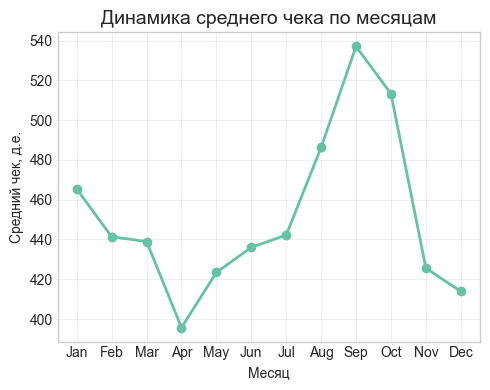

In [26]:
# Расчет среднего чека по месяцам
monthly_revenue = data.groupby('Month')['TotalPrice'].sum()
monthly_orders = data.groupby('Month')['InvoiceNo'].nunique()
monthly_avg_check = monthly_revenue / monthly_orders

# Визуализация
plt.figure(figsize=(5, 4))

# Строим линию среднего чека
plt.plot(monthly_avg_check.index, monthly_avg_check.values, marker='o', linewidth=2)
plt.title('Динамика среднего чека по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек, д.е.')
plt.xticks(range(1, 13), name_month)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

Выручка и заказы распределены неравномерно, поэтому стандартные календарные сезоны плохо отражают поведение клиентов. Из цифр четко видны три уникальных паттерна поведения: «Пиковый период» (Август, Сентябрь, Октябрь). Клиенты закупаются крупными партиями. «Массовый ритейл / Распродажи» (Ноябрь, Декабрь, Апрель) — средний чек падает до минимума, хотя объемы заказов в ноябре огромны. Это период скидок. «Стабильный межсезонный период» (Все остальные месяцы) — средний чек стабилен. Создадим новый признак описывающий нашу сезонность покупок.

In [27]:
purchase_behavior_map = {
    8: 'Peak', 9: 'Peak', 10: 'Peak',
    4: 'Promo', 11: 'Promo', 12: 'Promo',
    1: 'Stable', 2: 'Stable', 3: 'Stable',
    5: 'Stable', 6: 'Stable', 7: 'Stable'
}

# Задаем правильный порядок категорий
behavior_type = pd.CategoricalDtype(
    categories=["Peak", "Stable", "Promo"], 
    ordered=True
)
data['Purchase_Season_Type'] = data['Month'].map(purchase_behavior_map).astype(behavior_type)

Несмотря на то, что ноябрь был объединён с другими месяцами распродаж в признаке Purchase_Season_Type из-за схожего невысокого среднего чека, по физическому объёму транзакций и плотности заказов этот месяц является абсолютным аномальным гигантом. Создание признаков для каждого месяца или часа приведёт к опасной мультиколлинеарности (избыточности данных) и запутает алгоритмы кластеризации. Поэтому, чтобы модель сегментации могла чётко отделить уникальный сверхобъём Черной пятницы от обычных промо-периодов, мы создаём единственный точечный бинарный маркер — IsNovember.

In [28]:
data['IsNovember'] = (data['Month'] == 11).astype('int8')

Теперь переходим к микроциклам внутри суток. Нам нужно проанализировать, в какие часы и периоды клиенты наиболее активны, чтобы понять их суточные паттерны.

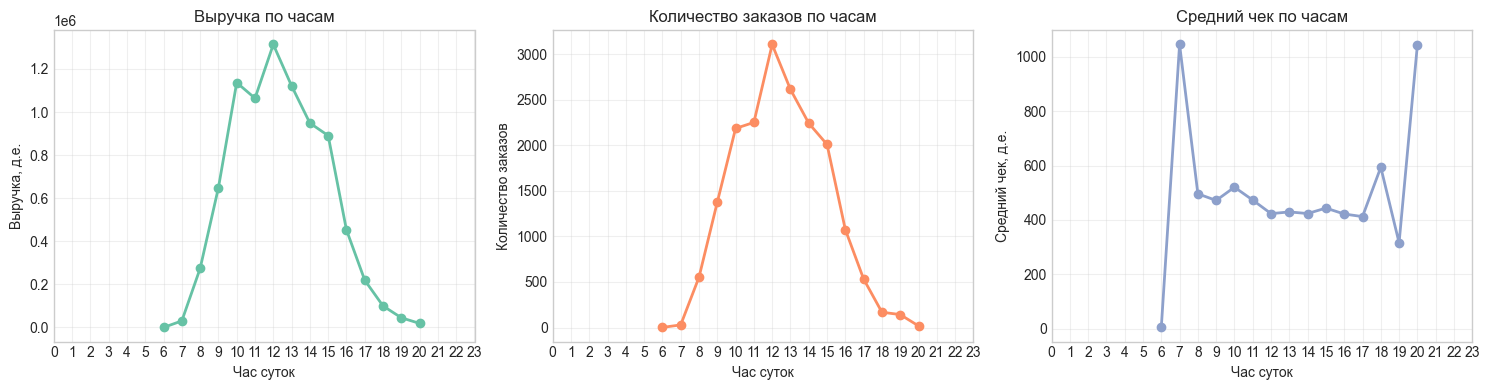

In [29]:
# Агрегируем данные по часам
hourly_revenue = data.groupby('Hour')['TotalPrice'].sum()
hourly_orders = data.groupby('Hour')['InvoiceNo'].nunique()
hourly_avg_check = hourly_revenue / hourly_orders

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# График 1: Выручка по часам
axes[0].plot(
    hourly_revenue.index, hourly_revenue.values, 
    marker='o', linewidth=2, color=colors[0]
)
axes[0].set_title('Выручка по часам', fontsize=12)
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Выручка, д.е.')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, alpha=0.3)

# График 2: Количество заказов по часам
axes[1].plot(
    hourly_orders.index, hourly_orders.values, 
    marker='o', linewidth=2, color=colors[1]
)
axes[1].set_title('Количество заказов по часам', fontsize=12)
axes[1].set_xlabel('Час суток')
axes[1].set_ylabel('Количество заказов')
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, alpha=0.3)

# График 3: Средний чек по часам
axes[2].plot(
    hourly_avg_check.index, hourly_avg_check.values, 
    marker='o', linewidth=2, color=colors[2]
)
axes[2].set_title('Средний чек по часам', fontsize=12)
axes[2].set_xlabel('Час суток')
axes[2].set_ylabel('Средний чек, д.е.')
axes[2].set_xticks(range(0, 24))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show();

**Вывод**:  Графики показывают, что основная активность магазина сосредоточена между 06:00 и 20:00 с явным розничным пиком в полдень (12:00), где максимальные объемы заказов сочетаются с минимальным средним чеком. В то же время линия среднего чека ведет себя волнообразно, демонстрируя заметные колебания на протяжении дня. Чтобы сгладить случайный часовой шум малых чисел и проверить, носят ли эти колебания системный характер, перейдем к проверке статистических гипотез для трех операционных интервалов: Morning (06:00 – 11:00), Afternoon (11:00 – 16:00) и Evening (16:00 – 21:00).

**Гипотеза 1**: Общая гипотеза
- **$H_{0}$**: Распределения средних чеков в операционных интервалах Morning, Afternoon и Evening идентичны (статистически значимых различий между группами нет).
- **$H_{1}$**: Распределения средних чеков как минимум в одном из операционных интервалов статистически значимо сдвинуты относительно остальных.

Если гипотеза подтвердится, необходимо провести попарный тест, чтобы исключить эффект ложноположительного результата (ошибки первого рода) из-за множественного тестирования.

In [30]:
# Объединение чеков в категории для проверки гипотезы
checks_morning = data[data['Hour'] < 11].groupby('InvoiceNo')['TotalPrice'].sum()
checks_afternoon = data[(data['Hour'] >= 11) & (data['Hour'] < 16)].groupby('InvoiceNo')['TotalPrice'].sum()
checks_evening = data[data['Hour'] >= 16].groupby('InvoiceNo')['TotalPrice'].sum()
get_test_recommendation([checks_morning, checks_afternoon, checks_evening])

Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 3: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.018 -> Дисперсии не одинаковы
Рекомендация: для трех и более независимых групп с ненормальным распределением применяется критерий Краскела-Уоллиса: scipy.stats.kruskal


In [31]:
# Статистический тест Краскела — Уоллиса
stat, p_value = stats.kruskal(checks_morning, checks_afternoon, checks_evening)
get_gip(p_value)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Так как гипотеза подтвердилась проведем попарные сравнения:
- **$H_{0}^{pair}$**: Два конкретных операционных интервала не имеют статистически значимых различий по суммам чеков.
- **$H_{1}^{pair}$**: Между двумя конкретными операционными интервалами есть статистически значимые различия.

In [32]:
# Попарные сравнения через критерий Манна-Уитни
_, p_val_m_a = stats.mannwhitneyu(checks_morning, checks_afternoon, alternative='two-sided')
_, p_val_a_e = stats.mannwhitneyu(checks_afternoon, checks_evening, alternative='two-sided')
_, p_val_m_e = stats.mannwhitneyu(checks_morning, checks_evening, alternative='two-sided')

# Применяем поправку Бонферрони вручную (умножаем p-value на 3 сравнения)
print("Сравнение Morning vs Afternoon:")
get_gip(p_val_m_a * 3)
print("\nСравнение Afternoon vs Evening:")
get_gip(p_val_a_e * 3)
print("\nСравнение Morning vs Evening:")
get_gip(p_val_m_e * 3)

Сравнение Morning vs Afternoon:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.

Сравнение Afternoon vs Evening:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.

Сравнение Morning vs Evening:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [33]:
# Так как нулевая гипотеза отвергнута, создаем категориальный признак TimeOfDay
def get_time_of_day(hour):
    if hour < 11:
        return 'Morning'
    elif 11 <= hour < 16:
        return 'Afternoon'
    else:
        return 'Evening'
time_type = pd.CategoricalDtype(categories=['Morning', 'Afternoon', 'Evening'], ordered=True)
data['TimeOfDay'] = data['Hour'].apply(get_time_of_day).astype(time_type)

Перейдем к анализу данных по дням недели

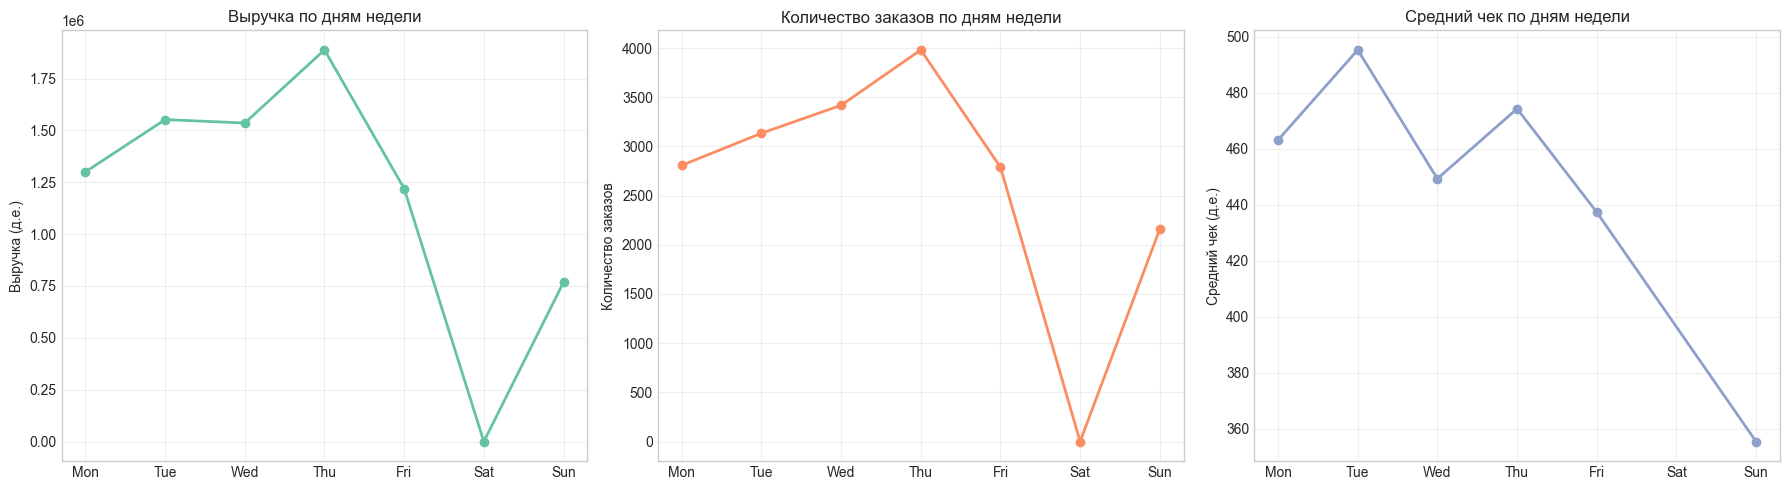

In [34]:
# Группирую данные по числовому признаку Weekday
weekday_revenue = data.groupby('Weekday')['TotalPrice'].sum().reindex(range(7), fill_value=0)
weekday_orders = data.groupby('Weekday')['InvoiceNo'].nunique().reindex(range(7), fill_value=0)
weekday_avg_check = weekday_revenue / weekday_orders

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_wk = sns.color_palette("Set2", 3)
name_day = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# График 1: Выручка по дням недели
axes[0].plot(
    weekday_revenue.index, weekday_revenue.values, 
    marker='o', linewidth=2, color=colors_wk[0]
)
axes[0].set_title('Выручка по дням недели', fontsize=12)
axes[0].set_ylabel('Выручка (д.е.)')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(name_day)
axes[0].grid(True, alpha=0.3)

# График 2: Количество заказов по дням недели
axes[1].plot(
    weekday_orders.index, weekday_orders.values, 
    marker='o', linewidth=2, color=colors_wk[1]
)
axes[1].set_title('Количество заказов по дням недели', fontsize=12) # Исправили заголовок
axes[1].set_ylabel('Количество заказов')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(name_day)
axes[1].grid(True, alpha=0.3)

# График 3: Средний чек по дням недели
avg_check_clean = weekday_avg_check.dropna()
axes[2].plot(
    avg_check_clean.index, avg_check_clean.values, 
    marker='o', linewidth=2, color=colors_wk[2]
)
axes[2].set_title('Средний чек по дням недели', fontsize=12)
axes[2].set_ylabel('Средний чек (д.е.)')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(name_day)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show();

**Вывод:** Анализ недельной активности выявил ключевую структурную особенность данных — полное отсутствие транзакций в субботу, что свидетельствует о фиксированном выходном дне компании. Главным пиком недели выступает четверг (около 4000 заказов на 1,9 млн.д.е.), после чего активность падает. При этом в воскресенье зафиксирован уникальный паттерн: на фоне относительно стабильного потока заказов средний чек падает до недельного минимума, что указывает на смену аудитории с крупных оптовиков на мелкий розничный сегмент. Для проверки, носит ли это воскресное падение системный характер, далее будет проведена проверка статистической значимости различий чека будней и воскресенья.

**Гипотеза 2**: Влияние дня недели на покупательскую активность
- $H_0$: Размеры чеков (TotalPrice) в рабочие дни (будни) и в воскресенье не имеют статистически значимых различий.
- $H_1$: Размеры чеков (TotalPrice) в воскресенье статистически значимо отличаются от будних дней.

Если гипотеза подтвердится, создаём новый бинарный признак IsSunday (1 — Воскресенье, 0 — будние дни с понедельника по пятницу).

In [35]:
# Делим чеки на две группы: будни (0-4) и воскресенье (6)
checks_business_days = data[data['Weekday'] <= 4].groupby('InvoiceNo')['TotalPrice'].sum()
checks_sunday = data[data['Weekday'] == 6].groupby('InvoiceNo')['TotalPrice'].sum()
get_test_recommendation([checks_business_days, checks_sunday])

Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.000 -> Дисперсии не одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [36]:
# Запускаем тест Манна-Уитни
stat, p_value = stats.mannwhitneyu(checks_business_days, checks_sunday, alternative='two-sided')
get_gip(p_value)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [37]:
# Создаем бинарный признак IsSunday
data['IsSunday'] = (data['Weekday'] == 6).astype(int)

**Итоги**: Изучение графиков и проверка гипотез помогли нам найти четкие правила в поведении клиентов и создать новые признаки для будущей модели.
- Сезоны покупок (Purchase_Season_Type). Год разделился на три логических периода: время крупных оптовых закупщиков (конец лета — осень), сезон распродаж с низким чеком (ноябрь, декабрь, апрель) и стабильные обычные месяцы.
- Отдельно мы пометили ноябрь флажком IsNovember, так как из-за Черной пятницы этот месяц бьет все рекорды по объему заказов.
- Время суток (TimeOfDay). Математический тест подтвердил, что поведение клиентов сильно отличается утром, днем и вечером. Мы зафиксировали эти три интервала, чтобы модель понимала, в какое время совершаются самые дорогие покупки.
- Выходные (IsSunday). Данные показали, что по субботам магазин вообще не работает. При этом в воскресенье заказов идет много, но средний чек падает до минимума. Тест доказал, что в воскресенье закупаются обычные розничные клиенты, а в будни — крупные оптовики. Мы зафиксировали это признаком IsSunday.

#### 2.2.3 Анализ по странам

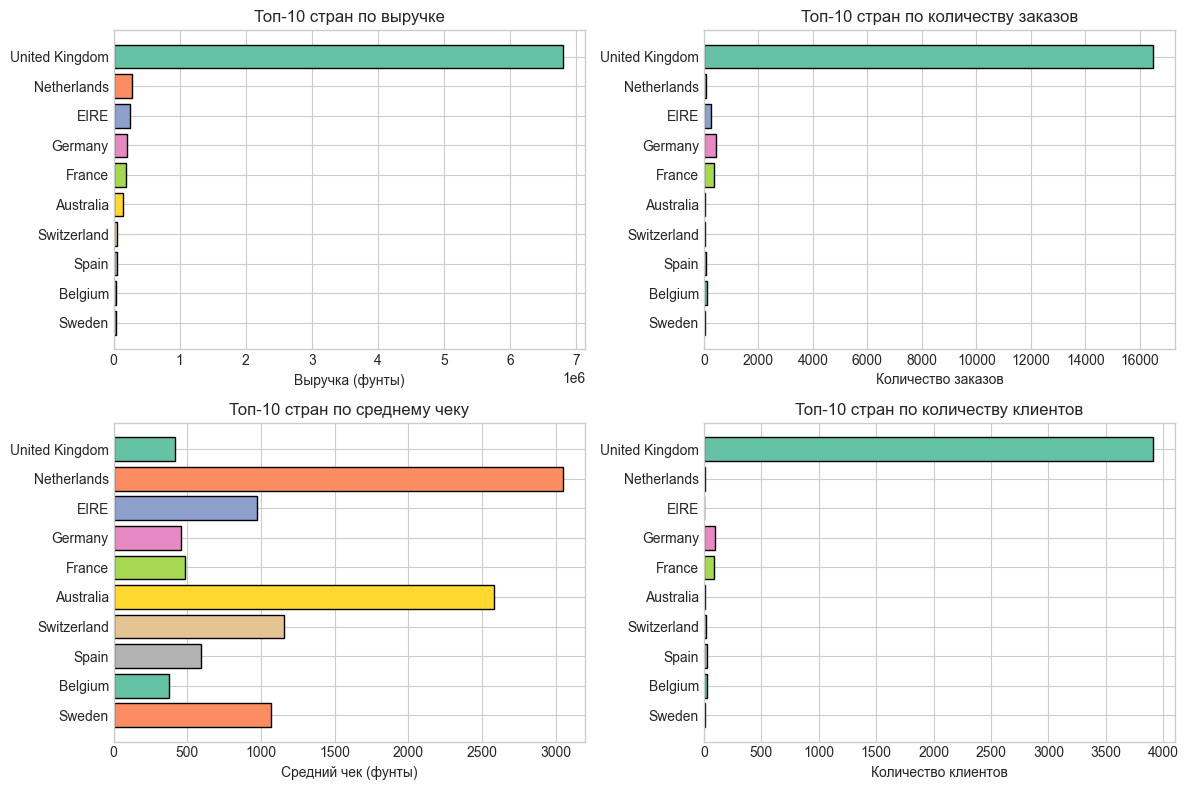

In [38]:
# Группирую заказы и выручку по странам
country_stats = data.groupby('Country').agg({
    'CustomerID': 'nunique',  # Количество клиентов
    'InvoiceNo': 'nunique',   # Количество заказов
    'TotalPrice': 'sum'       # Общая выручка
}).round(0).sort_values('TotalPrice', ascending=False)

country_stats.columns = ['Клиентов', 'Заказов', 'Выручка']
country_stats['Ср. чек'] = (
    country_stats['Выручка'] / country_stats['Заказов']
).round(2)

# Проанализируем топ-10 стран
top_countries = country_stats.head(10)

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors = sns.color_palette("Set2", 10)

# График 1: Выручка по странам (топ-10)
axes[0, 0].barh(
    top_countries.index, top_countries['Выручка'], color=colors
)
axes[0, 0].set_xlabel('Выручка (фунты)')
axes[0, 0].set_title('Топ-10 стран по выручке')
axes[0, 0].invert_yaxis()  # Чтобы UK был на самом верху

# График 2: Количество заказов по странам (топ-10)
axes[0, 1].barh(
    top_countries.index, top_countries['Заказов'], color=colors
)
axes[0, 1].set_xlabel('Количество заказов')
axes[0, 1].set_title('Топ-10 стран по количеству заказов')
axes[0, 1].invert_yaxis()

# График 3: Средний чек по странам (топ-10)
axes[1, 0].barh(
    top_countries.index, top_countries['Ср. чек'], color=colors
)
axes[1, 0].set_xlabel('Средний чек (фунты)')
axes[1, 0].set_title('Топ-10 стран по среднему чеку')
axes[1, 0].invert_yaxis()

# График 4: Количество клиентов по странам (топ-10)
axes[1, 1].barh(
    top_countries.index, top_countries['Клиентов'], color=colors
)
axes[1, 1].set_xlabel('Количество клиентов')
axes[1, 1].set_title('Топ-10 стран по количеству клиентов')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show();

**Вывод**: 

Великобритания полностью доминирует в продажах: на эту страну приходится более 90% всей выручки, заказов и покупателей. Чтобы этот гигантский масштаб домашнего рынка не запутал модель кластеризации, мы сразу создаем бинарный маркер IsUK (1 — Великобритания, 0 — другие страны).

При этом на графиках Нидерланды, Австралия, Ирландия и Швейцария выделяются аномально высоким средним чеком на фоне единичных клиентов. Чтобы проверить, действительно ли за границей сформировался устойчивый сегмент крупных закупщиков, или это случайный шум, перейдем к проверке статистической гипотезы.

**Гипотеза 3**: Высокий средний чек у отдельных стран
- $H_0$: Сумма покупки в странах с высоким средним чеком (Нидерланды, Австралия, Ирландия, Швейцария) не отличается от суммы покупки в остальных странах.
- $H_1$: Сумма покупки в этих странах отличается от остальных.

Если гипотеза подтвердится, мы создадим второй географический признак — маркер оптовых стран HighCheckCountry (1 — Нидерланды, Австралия, Ирландия, Швейцария; 0 — остальные).

In [39]:
# Подготовка данных для гипотезы
# Группируем данные до уровня чеков (один заказ = одна сумма)
invoice_checks = data.groupby(['InvoiceNo', 'Country'], as_index=False)['TotalPrice'].sum()

# Делим чеки на две группы по странам
high_check_countries = ['Netherlands', 'Australia', 'EIRE', 'Switzerland']
high_check_total = invoice_checks[invoice_checks['Country'].isin(high_check_countries)]['TotalPrice']
other_total = invoice_checks[~invoice_checks['Country'].isin(high_check_countries)]['TotalPrice']

# Выбираем тест
get_test_recommendation([high_check_total, other_total])

Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.000 -> Дисперсии не одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [40]:
stat, p = stats.mannwhitneyu(high_check_total, other_total, alternative='two-sided')
get_gip(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [41]:
# Создаем признаки
data['IsUK'] = (data['Country'] == 'United Kingdom').astype("int8")
data['HighCheckCountry'] = data['Country'].isin(high_check_countries).astype("int8")

**Вывод.** Статистический тест подтвердил, что в Нидерландах, Австралии, Ирландии и Швейцарии суммы чеков значимо выше, чем в остальных странах, что окончательно обосновывает выделение этих регионов в отдельный премиальный сегмент HighCheckCountry.

Переходим к следующему шагу — анализу сезонной выручки в разрезе стран, чтобы оценить, как географические рынки реагируют на календарные пики и распродажи.

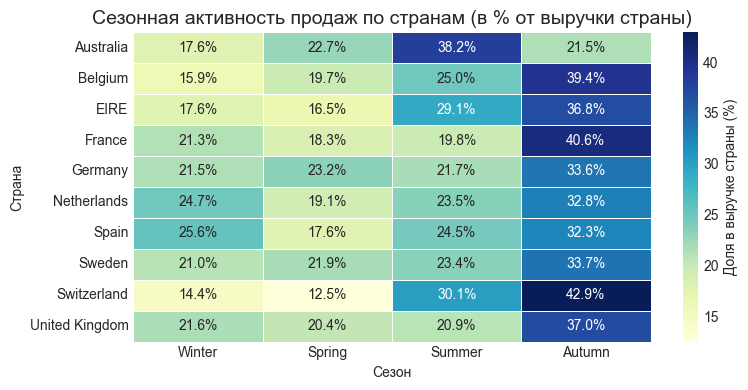

In [42]:
# Сезонная выручка по странам (топ-10 стран по общей выручке)
seasonal_country_revenue = (
    data[data['Country'].isin(top_countries.index)]
    .groupby(['Country', 'Season'])['TotalPrice']
    .sum()
    .unstack()
)
# Переводим выручку в проценты по строкам
seasonal_revenue_pct = seasonal_country_revenue.div(
    seasonal_country_revenue.sum(axis=1), axis=0
) * 100

# Визуализация
plt.figure(figsize=(8, 4))
sns.heatmap(
    seasonal_revenue_pct,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': 'Доля в выручке страны (%)'}
)

for text in plt.gca().texts:
    text.set_text(f"{text.get_text()}%")

plt.title('Сезонная активность продаж по странам (в % от выручки страны)', fontsize=14)
plt.xlabel('Сезон')
plt.ylabel('Страна')
plt.tight_layout()
plt.show();

**Вывод**: Для большинства европейских стран главным периодом выступает осень, генерирующая от 32% до 43% годовой выручки. Исключением стала Австралия, показавшая аномальный пик продаж в летние месяцы на уровне 38.2%. Поскольку крупные квартальные интервалы сильно сглаживают реальную динамику, для точного профилирования клиентов необходимо спуститься на уровень конкретных месяцев и изучить регулярность их заказов.

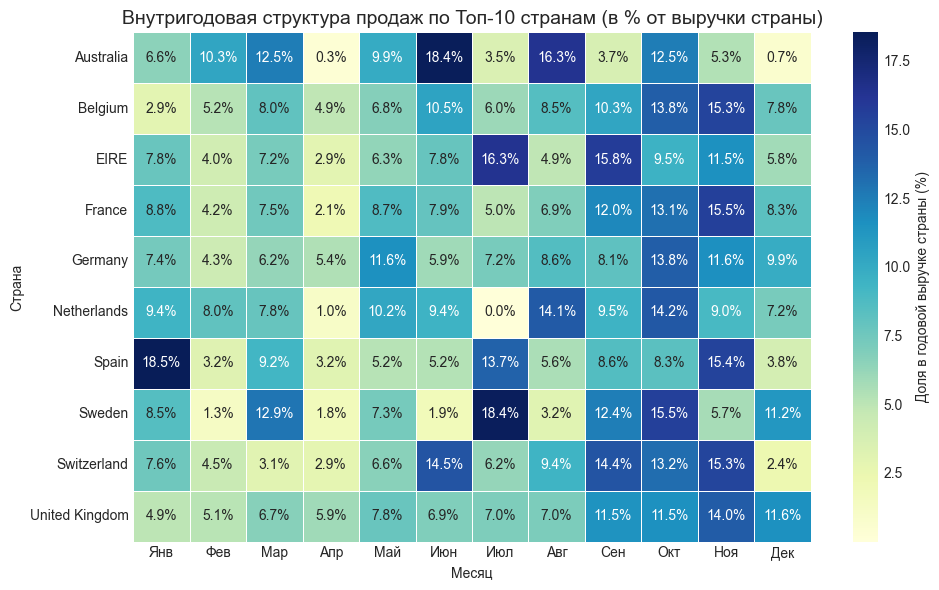

In [43]:
# Собираем помесячную выручку
month_revenue = (
    data[data['Country'].isin(top_countries.index)]
    .groupby(['Country', 'Month'])['TotalPrice']
    .sum()
    .unstack()
)
# Переводим в проценты внутри каждой страны
month_revenue_pct = month_revenue.div(month_revenue.sum(axis=1), axis=0) * 100

# Визуализация
plt.figure(figsize=(10, 6))
sns.heatmap(
    month_revenue_pct,
    cmap="YlGnBu",
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': 'Доля в годовой выручке страны (%)'}
)

for text in plt.gca().texts:
    text.set_text(f"{text.get_text()}%")
plt.title(
    'Внутригодовая структура продаж по Топ-10 странам (в % от выручки страны)', 
    fontsize=14
)
plt.xlabel('Месяц')
plt.ylabel('Страна')
plt.xticks(
    [x + 0.5 for x in range(12)],
    ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
     'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
)
plt.tight_layout()
plt.show();

**Вывод.** Помесячный анализ подтвердил, что для большинства ключевых рынков, включая Великобританию, Францию, Германию и Бельгию, главными месяцами продаж выступают октябрь и ноябрь, тогда как в апреле наблюдается сильный спад. Однако группа стран в лице Австралии, Швеции, Ирландии, Швейцарии, Испании и Нидерландов демонстрирует изолированные аномалии: мощные точечные вспышки продаж в начале или середине года при резких провалах в соседние месяцы. Это указывает на специфические локальные группы клиентов или разовые крупные контракты, которые сильно выбиваются из общего тренда.Чтобы модель сегментации могла безошибочно выделить клиентов с такой нестандартной календарной активностью и не смешивала их с регулярным рынком, мы объединяем эти страны с помощью бинарного признака IsOutlierCountry.

In [44]:
# Полный список стран с аномальной внутригодовой структурой продаж
outlier_countries = ['Spain', 'Netherlands', 'Australia', 'Switzerland', 'Sweden', 'EIRE']
data['IsOutlierCountry'] = data['Country'].isin(outlier_countries).astype('int8')

Ранее мы создали признак 'HighCheckCountry' (высокий средний чек по странам) и признак сезона 'Purchase_Season_Type' == 'Peak'. Если крупный клиент совершает транзакцию в стране с высоким чеком И в пиковый сезон (Peak), ценность такой транзакции для сегментации удваивается. Создадим чистый признак крупной закупки 'IsPurePeak':

In [45]:
# Признак равен 1, если совпали высокий чек страны и пиковый период компании
data['IsPurePeak'] = (
    (data['HighCheckCountry'] == 1) & 
    (data['Purchase_Season_Type'] == 'Peak')
).astype('int8')

**Итоги**: Исследование географии продаж помогло нам выявить сильные структурные различия между рынками и зафиксировать их в виде трех новых признаков.
- Домашний рынок (IsUK). Мы отделили Великобританию от остальных регионов, так как на неё приходится более 90% всех клиентов, заказов и выручки магазина.
- Премиальный сегмент (HighCheckCountry и IsPurePeak). Статистический тест доказал, что чеки в Нидерландах, Австралии, Ирландии и Швейцарии значимо выше, чем в остальном мире. Мы создали маркер оптовых стран, а также признак IsPurePeak, который подсвечивает транзакции, совершенные в этих прибыльных регионах именно в пиковые месяцы компании.
- Календарные аномалии (IsOutlierCountry). Помесячный анализ выручки выявил группу стран с нестандартным поведением — у них происходят изолированные, мощные вспышки продаж в нетипичные месяцы. Мы объединили их специальным флагом, чтобы алгоритм кластеризации не путал их с регулярным рынком.

#### 2.2.4 Анализ товаров (StockCode и Description)

**Вопрос 1**: Какие товары являются самыми популярными по количеству продаж и какие приносят наибольшую выручку? Генерируют ли лидеры продаж основные риски отмен?

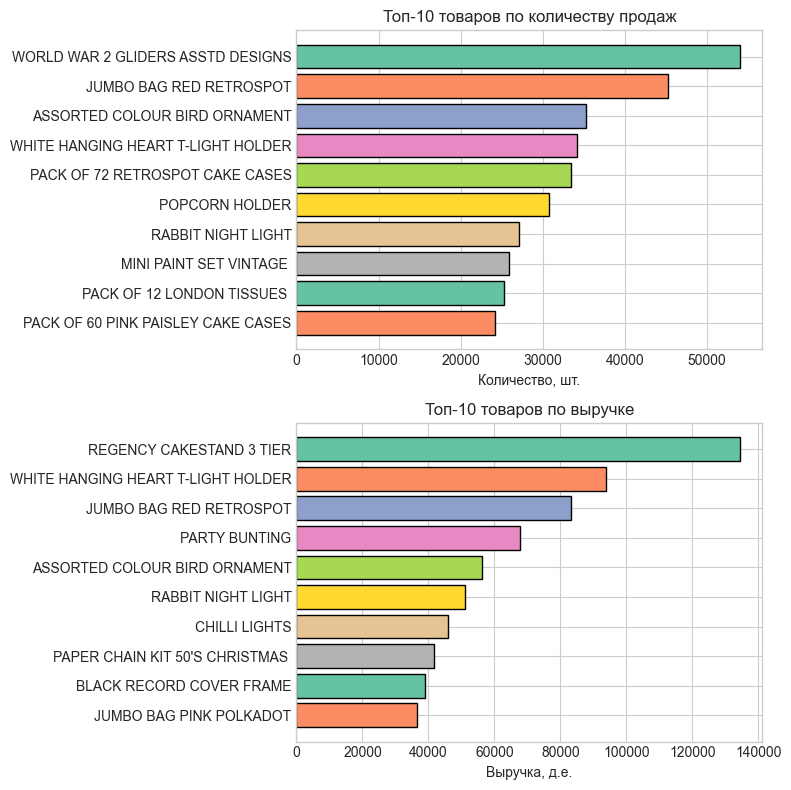

In [46]:
# Топ-10 по продажам и выручке
top_products_qty = (
    data.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products_revenue = (
    data.groupby("Description")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
colors = sns.color_palette("Set2", 10)

# График 1: Топ-10 по количеству продаж
axes[0].barh(top_products_qty.index, top_products_qty.values, color=colors)
axes[0].set_title("Топ-10 товаров по количеству продаж")
axes[0].set_xlabel("Количество, шт.")
axes[0].invert_yaxis()

# График 2: Топ-10 по выручке
axes[1].barh(top_products_revenue.index, top_products_revenue.values, color=colors)
axes[1].set_title("Топ-10 товаров по выручке")
axes[1].set_xlabel("Выручка, д.е.")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show();

**Вывод.** Абсолютным лидером по количеству проданных штук является товар WORLD WAR 2 GLIDERS ASSTD DESIGNS (более 50 000 шт.), в то время как по объему сгенерированной выручки на первом месте с огромным отрывом идет REGENCY CAKESTAND 3 TIER (более 130 000 д.е.). Лишь часть товаров (например, JUMBO BAG RED RETROSPOT, WHITE HANGING HEART T-LIGHT HOLDER и RABBIT NIGHT LIGHT) одновременно входят в топ-10 и по количеству, и по выручке, являясь ключевыми драйверами оборота компании.

Однако самые популярные товары закупаются огромными партиями. Из-за колоссальных объёмов они чисто физически могут генерировать наибольшее количество отмен, что искажает общую картину. Чтобы понять, действительно ли популярность товара создаёт для магазина повышенные риски отмен, нам нужно оценивать не абсолютные штуки, а относительную долю возвратов каждого товара (ReturnRate). Для проверки этой логики мы сравним показатели отмен у большой группы лидеров продаж со всем остальным ассортиментом.

**Гипотеза 4**: Влияние популярности товара на риски его отмены
- **$H_{0}$**: Доля возвратов (ReturnRate) у Топ-100 самых продаваемых товаров не отличается от доли возвратов у остального ассортимента.
- **$H_{1}$**: Доля возвратов у самых продаваемых товаров статистически значимо отличается от остального ассортимента.

Если гипотеза подтвердится, создаём признак IsPopularProduct (1 — товар входит в Топ-100 по продажам, 0 — рядовой ассортимент).

In [47]:
# Считаем успешные продажи и возвраты в отдельную переменную
sales_qty = data[data['Quantity'] > 0].groupby('Description')['Quantity'].sum()
canceled_qty = data.groupby('Description')['QuantityCanceled'].sum().abs()

# Объединяем в один датафрейм и убираем пропуски
product_return_rate = pd.DataFrame({
    'Quantity': sales_qty,
    'QuantityCanceled': canceled_qty
}).dropna()

# Считаем ReturnRate
product_return_rate["ReturnRate"] = (
    product_return_rate["QuantityCanceled"]
    / product_return_rate["Quantity"]
    * 100
).round(2)

# Выделяем Топ-100 лидеров продаж
top100_desc = sales_qty.sort_values(ascending=False).head(100).index

# Разделяем показатели отмен на две независимые группы
return_rates_popular = product_return_rate.loc[
    product_return_rate.index.isin(top100_desc), "ReturnRate"
]
return_rates_other = product_return_rate.loc[
    ~product_return_rate.index.isin(top100_desc), "ReturnRate"
]

# Вызываем автоматический подбор теста
get_test_recommendation([return_rates_popular, return_rates_other], is_dependent=False)

Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.437 -> Дисперсии одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [48]:
# Выполняем тест Манна-Уитни
stat, p = stats.mannwhitneyu(
    return_rates_popular, return_rates_other, alternative="two-sided"
)
get_gip(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [49]:
# p-value подтверждает значимость — создаем признак
data["IsPopularProduct"] = data["Description"].isin(top100_desc).astype("int8")

**Вывод.** Абсолютным лидером по количеству продаж является товар WORLD WAR 2 GLIDERS ASSTD DESIGNS, а по выручке — REGENCY CAKESTAND 3 TIER. При этом статистический тест строго доказал, что топ-100 самых продаваемых товаров действительно имеют значимо другой уровень рисков отмен (ReturnRate) по сравнению с остальным ассортиментом, что полностью подтверждает влияние популярности товара на возвраты и обосновывает создание признака IsPopularProduct.

**Вопрос 2**: Какие товары имеют самый высокий уровень возвратов и как риски отмены связаны с их розничной стоимостью? Коррелирует ли цена за единицу товара с вероятностью того, что заказ будет аннулирован?

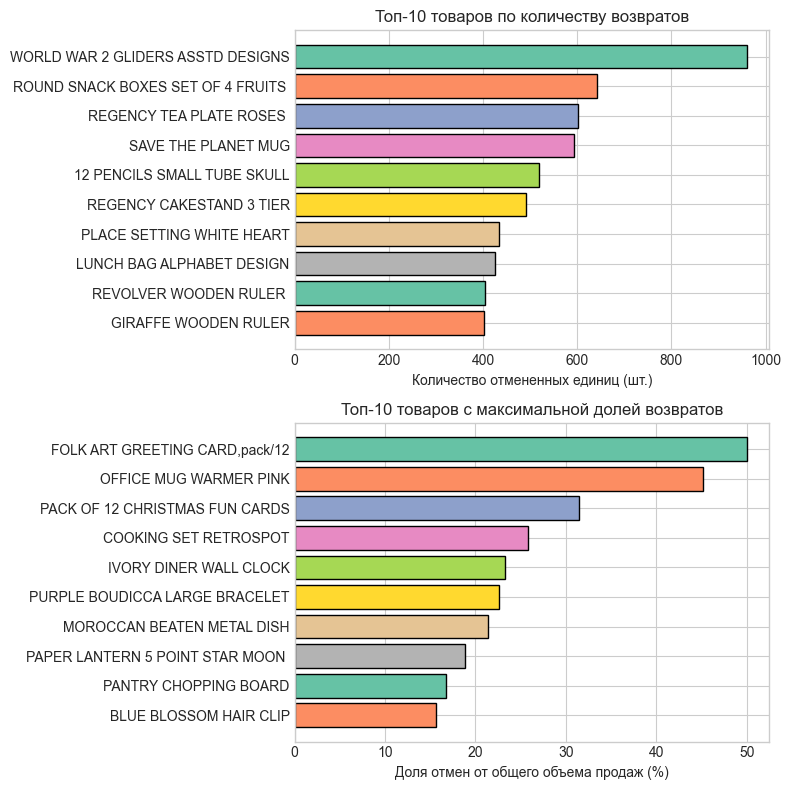

In [50]:
# Расчет Топ-10 по возвратам и доле возвратов
top_products_returns = (
    data.groupby("Description")["QuantityCanceled"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Отсекаем продажи менее 10 штук, чтобы убрать единичные браки и тесты
min_sales_filter = product_return_rate["Quantity"] > 10
high_return_products = (
    product_return_rate[min_sales_filter]
    .sort_values("ReturnRate", ascending=False)
    .head(10)
)

# Визуализация
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
colors = sns.color_palette("Set2", 10)

# График 3: Топ-10 по количеству возвратов
axes[0].barh(
    top_products_returns.index, top_products_returns.values, color=colors
)
axes[0].set_title("Топ-10 товаров по количеству возвратов")
axes[0].set_xlabel("Количество отмененных единиц (шт.)")
axes[0].invert_yaxis()

# График 4: Топ-10 по доле возвратов (%)
axes[1].barh(
    high_return_products.index,
    high_return_products["ReturnRate"],
    color=colors,
)
axes[1].set_title("Топ-10 товаров с максимальной долей возвратов")
axes[1].set_xlabel("Доля отмен от общего объема продаж (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show();

**Вывод.** Лидером по абсолютному числу отмен ожидаемо стал хит продаж WORLD WAR 2 GLIDERS ASSTD DESIGNS (почти 1000 аннулированных штук), однако по относительной доле возвратов (ReturnRate) на первом месте находится FOLK ART GREETING CARD, pack/12 с критическим уровнем отмен в 50%. Так как большинство товаров с максимальным процентом возвратов не входят в топ общего оборота, это подтверждает, что риски отмен специфичны для отдельных позиций. Чтобы проверить, связаны ли эти риски с розничной ценой товаров, перейдем к статистическому тесту.

**Гипотеза 5**: Связь между стоимостью товара и частотой его возврата
- **$H_{0}$**: Средняя цена за единицу (UnitPrice) у товаров с высокой долей отмен не отличается от цены стабильно выкупаемых товаров.
- **$H_{1}$**: Товары с высокой долей отмен имеют статистически значимо отличную среднюю цену за единицу.

Если гипотеза подтвердится, создаём новый бинарный признак IsHighReturnRisk (1 — товар имеет долю возвратов строго более 10%, 0 — стабильный товар с низким уровнем отмен).

Прежде чем вызвать стат-тест, нам нужно добавить среднюю цену (UnitPrice) каждого товара в нашу изолированную таблицу product_return_rate, а затем разделить товары на две группы: «высокий риск отмен» (доля возвратов > 10%) и «стабильные товары» (доля возвратов $\le 10\%$).

In [51]:
# Считаем среднюю цену каждого товара по исходной базе
product_prices = data.groupby("Description")["UnitPrice"].mean()

# Добавляем цены в нашу переменную с метриками возвратов
product_return_rate["UnitPrice"] = product_return_rate.index.map(product_prices)

# Отсекаем редкие товары с продажами менее 10 штук
clean_rate_df = product_return_rate[product_return_rate["Quantity"] > 10].dropna()

# Разделяем цены товаров на две группы по условию гипотезы (порог 10%)
prices_high_risk = clean_rate_df.loc[clean_rate_df["ReturnRate"] > 10, "UnitPrice"]
prices_stable = clean_rate_df.loc[clean_rate_df["ReturnRate"] <= 10, "UnitPrice"]

# Передаем группы в автоматический подбор критерия
get_test_recommendation([prices_high_risk, prices_stable], is_dependent=False)

Группа 1: p-value (Shapiro) = 0.004 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.896 -> Дисперсии одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [52]:
# Выполняем тест Манна-Уитни
stat, p = stats.mannwhitneyu(prices_high_risk, prices_stable, alternative="two-sided")
get_gip(p)

p-value = 0.008
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [53]:
# Cоздаем признак и выводим средние цены
high_risk_descriptions = prices_high_risk.index
data["IsHighReturnRisk"] = data["Description"].isin(high_risk_descriptions).astype("int8")

**Вывод.** Лидером по общему объёму отмен является товар WORLD WAR 2 GLIDERS ASSTD DESIGNS, а по относительной доле возвратов на первом месте находится FOLK ART GREETING CARD, pack/12 (50% отмен). Статистический тест строго доказал, что розничная стоимость товара напрямую связана с вероятностью его аннулирования: товары с высоким риском отмен имеют значимо отличную цену от стабильных позиций. Это полностью подтверждает связь цены с отказами и обосновывает создание признака IsHighReturnRisk.

#### 2.2.5.  Анализ структуры транзакций и объёма корзины

**Вопрос:** Какова структура объема заказов в магазине? Сколько уникальных товаров (строк) обычно содержит один чек (InvoiceNo), и существуют ли аномально огромные корзины, указывающие на скрытые профили покупателей?

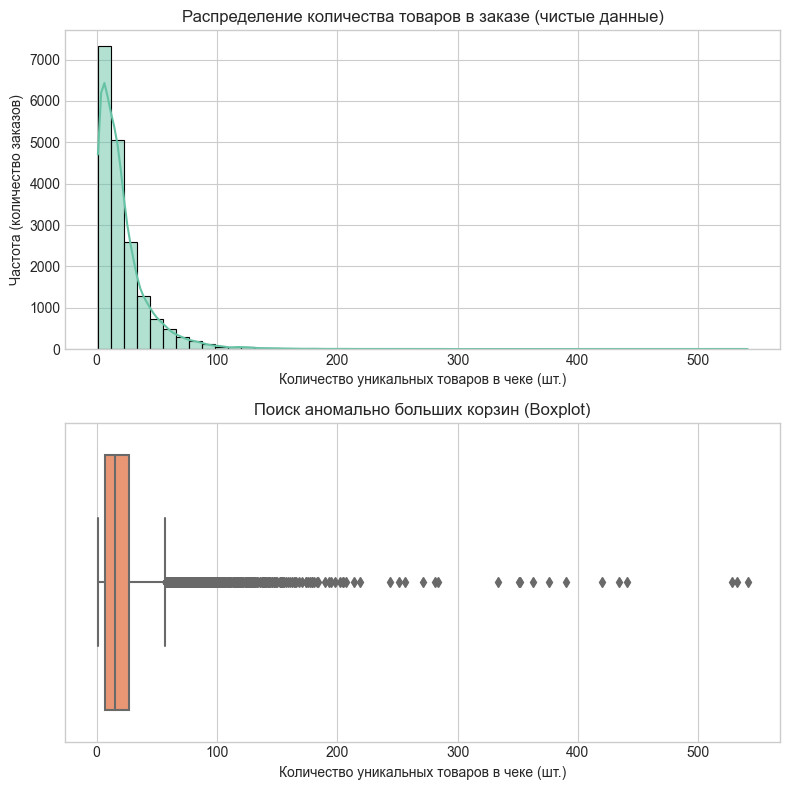

In [54]:
# Фильтруем данные: считаем размер корзины только для успешных покупок
successful_sales = data[data['Quantity'] > 0]
order_sizes = successful_sales.groupby("InvoiceNo")["StockCode"].count()

# Визуализация распределения размера корзины
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
colors = sns.color_palette("Set2")

# Общая гистограмма сглаженного распределения
sns.histplot(order_sizes, bins=50, kde=True, ax=axes[0], color=colors[0])
axes[0].set_title("Распределение количества товаров в заказе (чистые данные)")
axes[0].set_xlabel("Количество уникальных товаров в чеке (шт.)")
axes[0].set_ylabel("Частота (количество заказов)")

# Диаграмма размаха (Boxplot) для поиска выбросов и гигантских корзин
sns.boxplot(x=order_sizes, ax=axes[1], color=colors[1])
axes[1].set_title("Поиск аномально больших корзин (Boxplot)")
axes[1].set_xlabel("Количество уникальных товаров в чеке (шт.)")

plt.tight_layout()
plt.show();

По графикам и форме распределения видно сильно скошенное распределение с «длинным хвостом» (выбросами) вправо. Большинство заказов сосредоточено у левого края, но на Boxplot мы видим огромную россыпь черных точек — это аномально большие, гигантские корзины, которые содержат сотни уникальных позиций. Такие заказы почти со 100% вероятностью формирует совершенно иной сегмент клиентов.

Чтобы отсечь обычную розницу от профессиональных закупщиков, нам нужно проверить, отличаются ли финансово заказы с аномально большими корзинами от стандартных покупок.В качестве границы «крупной корзины» используем значение $Q3 + 1.5 \times IQR$ (верхний ус Boxplot). По графику этот ус заканчивается примерно на уровне 60 товаров. Все, что выше — признано математическим выбросом (аномалией).

**Гипотеза 6**: Влияние размера корзины на общую стоимость заказа

- **$H_{0}$**: Общая стоимость заказа (TotalPrice) у транзакций с гигантской корзиной (более 60 уникальных товаров) не отличается от стоимости стандартных заказов.
- **$H_{1}$**: Общая стоимость заказа у транзакций с гигантской корзиной статистически значимо отличается от стандартных заказов.

Если гипотеза подтвердится, создаём новый бинарный признак Big_Basket (1 — в заказе более 60 уникальных товаров, 0 — стандартная розничная корзина).

In [55]:
# Считаем общую стоимость (TotalPrice) каждого успешного заказа
successful_orders = data[data['Quantity'] > 0]
invoice_data = successful_orders.groupby('InvoiceNo').agg({
    'StockCode': 'count',   # Размер корзины (количество строк)
    'TotalPrice': 'sum'     # Общая стоимость всего заказа
})

# Рассчитываем точную границу верхнего уса Boxplot (Q3 + 1.5 * IQR)
q1 = invoice_data['StockCode'].quantile(0.25)
q3 = invoice_data['StockCode'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr

print(f"Рассчитанный порог аномальной корзины: {outlier_threshold:.1f} товаров")

# 3. Разделяем общую стоимость заказов на две группы по вычисленному порогу
large_baskets_revenue = invoice_data.loc[
    invoice_data['StockCode'] > outlier_threshold, 'TotalPrice'
]
standard_baskets_revenue = invoice_data.loc[
    invoice_data['StockCode'] <= outlier_threshold, 'TotalPrice'
]

# Вызываем автоматический подбор критерия
get_test_recommendation([large_baskets_revenue, standard_baskets_revenue], is_dependent=False)

Рассчитанный порог аномальной корзины: 57.0 товаров
Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.000 -> Дисперсии не одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [56]:
# Выполняем тест Манна-Уитни
stat, p = stats.mannwhitneyu(
    large_baskets_revenue, standard_baskets_revenue, alternative="two-sided"
)
get_gip(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [57]:
# Находим список номеров заказов, которые превысили порог в 57 товаров
large_basket_invoices = invoice_data[invoice_data['StockCode'] > 57].index

# Создаем признак Big_Basket в основной таблице
data['Big_Basket'] = data['InvoiceNo'].isin(large_basket_invoices).astype('int8')

**Вывод.** Расчет математической границы выбросов по методу межквартильного размаха позволил установить точный порог крупной корзины на уровне 57 уникальных товаров. Статистический тест строго доказал, что общая стоимость заказов с гигантской корзиной значимо отличается от стандартных розничных покупок. Это полностью подтверждает скрытое присутствие сегмента профессиональных закупщиков и обосновывает введение нового бинарного признака Big_Basket для модели кластеризации.

#### 2.2.6. Исследование клиентской базы и распределения повторных покупок

**Вопрос.** Как распределены активность и финансовая ценность клиентов внутри нашей базы? Какая доля покупателей совершает повторные заказы, и наблюдается ли сильное неравенство в распределении выручки на одного клиента?

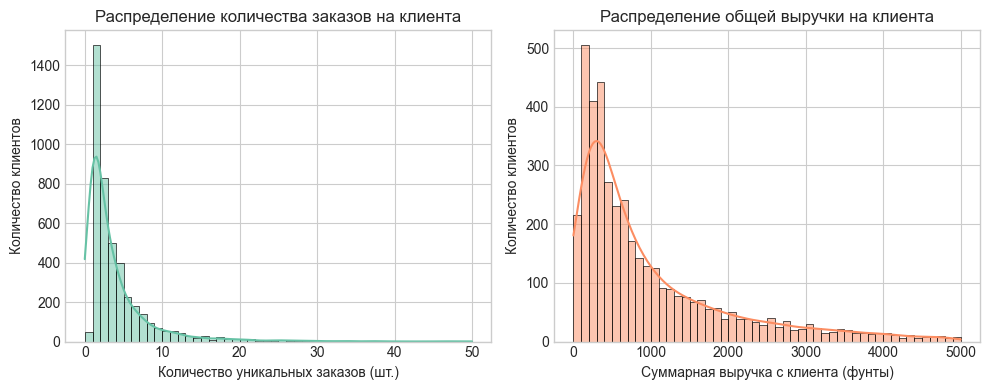

In [58]:
# Группируем базовую активность на уровне уникальных CustomerID
customer_orders = data.groupby("CustomerID")["InvoiceNo"].nunique()
customer_revenue = data.groupby("CustomerID")["TotalPrice"].sum()

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = sns.color_palette("Set2", 2)

# Распределение количества заказов (с ограничением до 50 для наглядности)
sns.histplot(
    customer_orders[customer_orders <= 50],
    bins=50,
    ax=axes[0],
    color=colors[0],
    kde=True,
)
axes[0].set_title("Распределение количества заказов на клиента")
axes[0].set_xlabel("Количество уникальных заказов (шт.)")
axes[0].set_ylabel("Количество клиентов")

# Распределение выручки (с ограничением до 5000 для наглядности)
sns.histplot(
    customer_revenue[customer_revenue <= 5000],
    bins=50,
    ax=axes[1],
    color=colors[1],
    kde=True,
)
axes[1].set_title("Распределение общей выручки на клиента")
axes[1].set_xlabel("Суммарная выручка с клиента (фунты)")
axes[1].set_ylabel("Количество клиентов")

plt.tight_layout()
plt.show();

Форма графиков наглядно показала, что у нас есть как «клиенты-однодневки», так и очень лояльные покупатели. Однако для создания точной модели сегментации нам нужно перевести эти визуальные наблюдения в строгие математические факты и проверить две важные гипотезы.

**Гипотеза 7**: Влияние количества заказов на общую выручку от клиента

Поскольку графики показывают длинные хвосты в обе стороны, нам нужно математически доказать, что частота покупок напрямую связана с финансовой ценностью клиента для компании. Для этого мы оценим силу связи между количеством заказов покупателя и его суммарной выручкой.

- **$H_{0}$**: Коэффициент ранговой корреляции Спирмена между количеством заказов клиента и его суммарной выручкой равен нулю (связи нет).
- **$H_{1}$**: Коэффициент корреляции Спирмена значимо отличается от нуля.

Если гипотеза подтвердится, мы создадим признак IsLoyal_5Plus (1 — клиент совершил 5 и более заказов, 0 — менее 5 заказов), чтобы зафиксировать ядро самых преданных покупателей.

**Гипотеза 8**: Различия в ценности заказов у разовых и повторных клиентов

Существует теория, что клиенты, которые возвращаются в магазин, начинают тратить больше за один раз, доверяя бренду. Мы проверим, действительно ли средний чек «одноразовых» покупателей отличается от тех, кто совершает повторные заказы, или их покупательская способность одинакова.

- **$H_{0}$**: Средний чек (TotalPrice за один заказ) у «одноразовых» клиентов (ровно 1 покупка) не отличается от среднего чека клиентов с повторными покупками.
- **$H_{1}**: Средний чек «одноразовых» клиентов статистически значимо отличается от чека повторных клиентов.

Если гипотеза подтвердится, мы создадим признак IsOneTimeCustomer (1 — у клиента ровно 1 заказ в истории, 0 — повторный клиент), который поможет модели изолировать случайных розничных покупателей.

In [59]:
# Подготовка данных на уровне уникальных клиентов
customer_df = (
    data.groupby("CustomerID")
    .agg(
        {
            "InvoiceNo": "nunique",  # Количество заказов
            "TotalPrice": "sum",     # Суммарная выручка
        }
    )
    .rename(columns={"InvoiceNo": "OrderCount", "TotalPrice": "TotalRevenue"})
)

# Считаем средний чек для каждого клиента (Общая выручка / Количество заказов)
customer_df["AvgCheck"] = customer_df["TotalRevenue"] / customer_df["OrderCount"]


# Тест гипотезы 7
corr, p_val = stats.spearmanr(
    customer_df["OrderCount"], customer_df["TotalRevenue"]
)

print("Проверка Гипотезы 7 (Заказы vs Выручка)")
print(f"Коэффициент корреляции Спирмена: {corr:.4f}")
get_gip(p_val)
print("-" * 50)

# Тест гипотезы 8
avg_check_one_time = customer_df[customer_df["OrderCount"] == 1]["AvgCheck"]
avg_check_repeat = customer_df[customer_df["OrderCount"] > 1]["AvgCheck"]
get_test_recommendation(
    [avg_check_one_time, avg_check_repeat], is_dependent=False
)

Проверка Гипотезы 7 (Заказы vs Выручка)
Коэффициент корреляции Спирмена: 0.8136
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.
--------------------------------------------------
Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.093 -> Дисперсии одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [60]:
stat, p = stats.mannwhitneyu(avg_check_one_time, avg_check_repeat, alternative="two-sided")
get_gip(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


In [61]:
# Выделяем списки CustomerID для каждой группы
loyal_customers_ids = customer_df[customer_df["OrderCount"] >= 5].index
onetime_customers_ids = customer_df[customer_df["OrderCount"] == 1].index

# Записываем новые признаки в основную таблицу
data["IsLoyal_5Plus"] = data["CustomerID"].isin(loyal_customers_ids).astype("int8")
data["IsOneTimeCustomer"] = data["CustomerID"].isin(onetime_customers_ids).astype("int8")

**Вывод.** Ранговая корреляция Спирмена доказала наличие сильнейшей взаимосвязи между частотой покупок и итоговым доходом с клиента $r = 0.81$, а тест Манна-Уитни подтвердил значимые различия в средних чеках разовых и постоянных покупателей. Эти результаты полностью подтверждают неоднородность клиентской базы и обосновывают добавление признаков IsLoyal_5Plus и IsOneTimeCustomer для будущей модели кластеризации.

#### 2.2.7. Анализ возвратов по клиентам

**Вопрос**: Какова доля клиентов, совершающих возвраты и отмены заказов, и существуют ли аномальные покупатели со сверхвысоким объёмом аннулированных товаров?

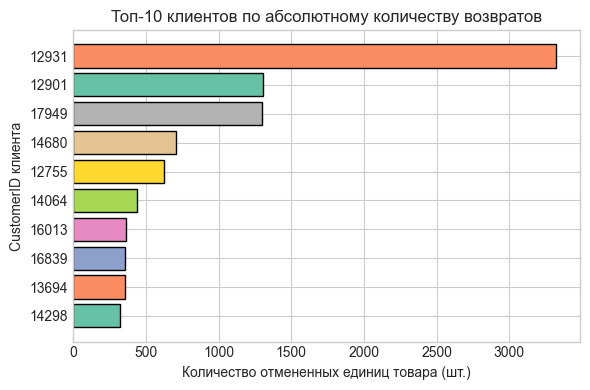

In [62]:
# Считаем суммарное количество отмененных товаров на каждого клиента
customer_returns = (
    data.groupby("CustomerID")["QuantityCanceled"]
    .sum()
    .sort_values(ascending=False)
)
customer_with_returns = customer_returns[customer_returns > 0]

# Выделяем Топ-10 клиентов по возвратам
top10_return_customers = customer_returns.head(10).iloc[::-1]

# Визуализация лидеров по отменам
plt.figure(figsize=(6, 4))
colors = sns.color_palette("Set2", 10)

plt.barh(
    [str(int(uid)) for uid in top10_return_customers.index],
    top10_return_customers.values,
    color=colors,
)
plt.title("Топ-10 клиентов по абсолютному количеству возвратов")
plt.xlabel("Количество отмененных единиц товара (шт.)")
plt.ylabel("CustomerID клиента")

plt.tight_layout()
plt.show();

**Вывод**: Анализ показал, что в магазине присутствует небольшая группа клиентов со сверхвысоким объёмом отмен. Абсолютным лидером стал покупатель с ID 12931, который аннулировал более 3300 единиц товара, что в разы превышает показатели других клиентов из топ-10. Такая аномальная активность может указывать как на технические ошибки при оформлении заказов, так и на специфику работы крупных оптовиков. Чтобы понять, являются ли эти отмены признаком проблемного поведения или они естественны для крупных клиентов, нам необходимо проверить две новые гипотезы.

**Гипотеза 9**: Связь между объёмом выкупленного товара и количеством отмен

Мы должны проверить, растут ли отмены пропорционально общему объёму закупок клиента. Если связь сильная, то отмены — это просто побочный эффект больших объёмов продаж.
- **$H_{0}$**: Коэффициент ранговой корреляции Спирмена между общим количеством выкупленных товаров (Quantity) и количеством отмен (QuantityCanceled) на одного клиента равен нулю (связи нет).
- **$H_{1}$**: Коэффициент корреляции Спирмена значимо отличается от нуля.

**Гипотеза 10**: Влияние фактора отмен на повторные визиты (лояльность)

Существует риск, что частые отмены вызваны негативным опытом (например, отсутствием товара на складе) и это заставляет клиентов уходить. Мы проверим, отличаются ли по своей лояльности (количеству визитов) клиенты, у которых были отмены, от тех, кто всегда выкупает заказы стабильно.

- **$H_{0}$**: Общее количество уникальных заказов (OrderCount) у клиентов, совершавших отмены, не отличается от количества заказов клиентов без отмен.
- **$H_{1}$**: Клиенты, совершавшие отмены, имеют статистически значимо другое количество заказов.

Если гипотезы подтвердятся, мы математически рассчитаем верхний порог нормы отмен по методу межквартильного размаха (IQR) и создадим признак клиентского риска — 'IsRiskUser'.

In [63]:
# Группируем списки покупок и отмен по каждому CustomerID
customer_profile = data.groupby("CustomerID").agg(
    {
        "Quantity": "sum",          # Всего выкуплено товаров
        "QuantityCanceled": "sum",  # Всего отменено товаров
        "InvoiceNo": "nunique",     # Общее количество заказов (лояльность)
    }
)
customer_profile.columns = ["TotalQty", "TotalCanceled", "OrderCount"]


# Тест гипотезы 9
corr, p = stats.spearmanr(
    customer_profile["TotalQty"], customer_profile["TotalCanceled"]
)
print(f"Коэффициент корреляции Спирмена: {corr:.4f}")
get_gip(p)
print("-" * 50)

# Тест гипотезы 10
orders_with_returns = customer_profile[customer_profile["TotalCanceled"] > 0][
    "OrderCount"
]
orders_no_returns = customer_profile[customer_profile["TotalCanceled"] == 0][
    "OrderCount"
]
get_test_recommendation([orders_with_returns, orders_no_returns], is_dependent=False)

Коэффициент корреляции Спирмена: 0.4331
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.
--------------------------------------------------
Группа 1: p-value (Shapiro) = 0.000 -> Отлично от нормального
Группа 2: p-value (Shapiro) = 0.000 -> Отлично от нормального
Проверка дисперсий: p-value (Levene) = 0.000 -> Дисперсии не одинаковы
Рекомендация: для двух независимых групп с ненормальным распределением применяется U-критерий Манна-Уитни: scipy.stats.mannwhitneyu


In [64]:
# Тест Манна-Уитни
_, p = stats.mannwhitneyu(orders_with_returns, orders_no_returns, alternative="two-sided")
get_gip(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу.


Результаты тестов открывают важнейшую закономерность для сегментации покупателей:
- Гипотеза 9: Коэффициент 0.4331 при p = 0.000 показывает умеренную, но высокозначимую положительную связь. Это доказывает, что отмены — во многом естественный спутник крупных объемов закупок. Чем больше клиент выкупает в штуках, тем чаще происходят корректировки и возвраты.
- Гипотеза 10: Тест зафиксировал высокозначимые различия в количестве заказов p < 0.001. Клиенты, совершавшие отмены, значимо отличаются по своей активности от тех, кто никогда ничего не возвращал. Это полностью опровергает страх того, что отмены заставляют лояльных клиентов уходить. Скорее наоборот: самые активные и постоянные покупатели сталкиваются с отменами чаще всего в силу большого числа транзакций.

In [65]:
# Считаем границы распределения отмен среди тех, у кого они были
returns_data = customer_profile[customer_profile["TotalCanceled"] > 0]["TotalCanceled"]

q1 = returns_data.quantile(0.25)
q3 = returns_data.quantile(0.75)
iqr = q3 - q1
cancel_threshold = q3 + 1.5 * iqr

print(f"Рассчитанный порог аномальных отмен: {cancel_threshold:.1f} шт.")

# Находим список CustomerID, у которых количество отмен строго выше порога
refuser_ids = customer_profile[customer_profile["TotalCanceled"] > cancel_threshold].index

# Фиксируем финальный бинарный признак IsRefuser в основной таблице data
data["IsRiskUser"] = data["CustomerID"].isin(refuser_ids).astype("int8")

Рассчитанный порог аномальных отмен: 27.0 шт.


**Вывод**. Статистический анализ подтвердил значимую связь между объемами закупок и количеством отмен r = 0.43, а также доказал, что клиенты с возвратами являются наиболее активным и лояльным ядром аудитории. Точный расчет межквартильного размаха позволил установить границу нормы на уровне 27 отмененных товаров, что полностью обосновывает введение целевого признака IsRiskUser для изоляции клиентов со сверхвысокими операционными рисками.

#### 2.2.8. Общие выводы

В ходе разведывательного анализа данных была полностью исследована структура продаж интернет-магазина. Визуальный анализ графиков и серия статистических проверок подтвердили сильную неоднородность клиентской базы, скрытое присутствие крупных оптовиков и наличие календарных аномалий.

Для того чтобы алгоритмы кластеризации (такие как k-means) могли безошибочно разделить аудиторию и не путались в масштабах, на основе стат-тестов были сформированы 9 бинарных и категориальных признаков:
- Временные циклы (Purchase_Season_Type, IsNovember, TimeOfDay, IsSunday). Математически доказано, что поведение клиентов жестко привязано к календарю. Мы зафиксировали три уникальных сезона покупок, выделили аномальный пик Черной пятницы в ноябре, разделили сутки на три статистически значимых интервала и изолировали розничное воскресенье от оптовых будней.
- Географическая сегментация (IsUK, HighCheckCountry, IsPurePeak). Мы изолировали домашний рынок Великобритании (более 90% базы). Статистический тест доказал, что Нидерланды, Австралия, Ирландия и Швейцария формируют обособленный класс с гигантскими чеками. Дополнительно создан маркер IsPurePeak для фиксации самых прибыльных оптовых закупок.
- Продуктовые и клиентские риски (IsOutlierCountry, IsPopularProduct, IsHighReturnRisk, IsLargeBasket, IsLoyal_5Plus, IsOneTimeCustomer, IsRiskUser). Математически рассчитаны границы нормы: аномальной признана корзина от 57 уникальных товаров (IsLargeBasket) и объем отмен от 27 штук на клиента (IsRiskUser). Тесты подтвердили, что популярность товара и его высокая цена напрямую связаны с рисками отмен, а сами клиенты с возвратами — это наиболее активное и лояльное ядро бизнеса. 

Все сгенерированные признаки готовы к этапу масштабирования и передачи в модель кластеризации.

In [66]:
# Для проверки
#data.info()

### 2.3. Построение RFM-таблицы и поиск RFM-выбросов

Мы добрались до самой интересной части нашей задачи. Нам предстоит сформировать признаки, на основе которых мы будем производить сегментацию клиентов.

Для этого давайте познакомимся с очень популярным методом для анализа потребительской ценности под названием RFM. 

Метод заключается в группировке клиентов на основе следующих параметров:
* Recency (Давность) — давность последней покупки клиента;
* Frequency (Частота) — общее количество покупок клиента;
* Monetary Value (Денежная ценность) — сколько денег потратил клиент.

Суть RFM-анализа состоит в том, что мы разделяем всех клиентов на группы в зависимости от того, как давно они сделали последнюю покупку, как часто покупали и насколько большой была сумма их заказов. 

Задача маркетологов — вести клиента в зону лояльных.

Мы можем рассчитать RFM-характеристики для каждого из клиентов в нашем датасете и на их основе с помощью методов кластеризации построить подобные сегменты клиентов, привязанные к нашим данным.

Чтобы получить RFM-таблицу, нам необходимо сгруппировать данные по идентификаторам клиента и рассчитать следующие  агрегированные характеристики:

* Recency для i-го клиента рассчитывается как разница между датой и временем последнего заказа и точкой отсчёта, переведённая в дни:
    $$t_0-max(t_{i1}, t_{i2},..., t_{iM})$$

    где $t_{ij}$ — дата и время совершения i-ым клиентом своей j-ой покупки.

    В качестве точки отсчёта $t_0$ берём дату на один день «старше», чем все наши данные. Это будет 10 декабря 2011 года (в формате datetime — '2011-12-10 00:00:00').

* Frequency рассчитывается как общее количество уникальных заказов, которые совершил i-ый клиент.
* Monetary Value рассчитывается как общая сумма денег, которую i-ый клиент потратил на наши товары (с учётом возвратов).

In [67]:
# Точка отсчёта (дата на один день позже максимальной даты в данных)
t0 = pd.Timestamp('2011-12-10 00:00:00')

# Группировка по клиентам для RFM
rfm_table = data.groupby('CustomerID', observed=True).agg({
    'InvoiceDate': lambda x: (t0 - x.max()).days,   # Recency (давность)
    'InvoiceNo': 'nunique',                         # Frequency (частота)
    'TotalPrice': 'sum'                             # Monetary (денежная ценность)
}).reset_index()

# Переименовываем колонки
rfm_table.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Проверяем результат
print("RFM-таблица (первые 10 строк)")
display(rfm_table.head(10))

# Основная статистика RFM
print("\nСтатистика RFM показателей")
display(rfm_table[['Recency', 'Frequency', 'Monetary']].describe().round(2))

RFM-таблица (первые 10 строк)


,CustomerID,Recency,Frequency,Monetary
0,12347,2,7,4310.00
1,12348,75,4,1437.24
2,12349,18,1,1457.55
3,12350,310,1,294.40
4,12352,36,6,1265.41
5,12353,204,1,89.00
6,12354,232,1,1079.40
7,12355,214,1,459.40
8,12356,22,3,2487.43
9,12357,33,1,6207.67



Статистика RFM показателей


,Recency,Frequency,Monetary
count,4324.00,4324.00,4324.00
mean,92.35,4.23,1911.24
std,100.26,7.58,8313.36
min,0.00,1.00,2.90
25%,17.00,1.00,299.66
50%,50.00,2.00,653.22
75%,143.00,5.00,1611.43
max,373.00,203.00,278742.02


После того как вы подготовите RFM-таблицу, визуализируйте каждую из трёх компонент, например, в виде коробчатых диаграмм (boxplot).

In [68]:
fig_1 = make_subplots(rows=1, cols=3, subplot_titles=("Recency", "Frequency", "Monetary"))

fig_1.add_trace(px.box(rfm_table, y='Recency')['data'][0], row=1, col=1)
fig_1.add_trace(px.box(rfm_table, y='Frequency')['data'][0], row=1, col=2)
fig_1.add_trace(px.box(rfm_table, y='Monetary')['data'][0], row=1, col=3)

fig_1.update_layout(showlegend=False, height=500, width=1200)
#fig_1.show()
#fig_1.write_html("data/html/fig_1.html")
plt.close()

<img src = 'data/image/fig_1.png'>

Ознакомится с интерактивным графиком можно по [ссылке](https://htmlpreview.github.io/?https://github.com/emozdir/Projects/blob/master/projects/project_6/data/html/fig_1.html)

**Вывод**. Диаграммы размаха наглядно подтверждают экстремальное смещение в данных. В базе присутствует скрытый сегмент сверхкрупных покупателей, которые совершают более 100 заказов и тратят свыше 190 тысяч фунтов стерлингов.Наличие таких экстремальных выбросов критически опасно для алгоритма KMeans, поскольку он вычисляет средние расстояния до центроидов и начнет подстраивать границы кластеров под единичных гигантов, полностью сломав сегментацию основной массы клиентов. Чтобы защитить модель от искажений и при этом сохранить ценную часть лояльной розничной базы, мы применим мягкую фильтрацию по квантилю 0.95. Это позволит отсечь верхний 5%-й хвост аномалий по показателям Frequency и Monetary.

In [69]:
# Вычисляем 95-й перцентиль для Frequency и Monetary
freq_95 = rfm_table['Frequency'].quantile(0.95)
monetary_95 = rfm_table['Monetary'].quantile(0.95)

# Удаляем выбросы
rfm_table_clean = rfm_table[
    (rfm_table['Frequency'] <= freq_95) & 
    (rfm_table['Monetary'] <= monetary_95)
].copy()

print(f"После удаления")
print(f"Размер RFM-таблицы до: {len(rfm_table)}")
print(f"Размер RFM-таблицы после: {len(rfm_table_clean)}")

После удаления
Размер RFM-таблицы до: 4324
Размер RFM-таблицы после: 4035


**Вывод.** Очистка данных по 95-му перцентилю позволила успешно отсечь 289 аномальных клиентов. Мы сохранили 4035 репрезентативных профилей (более 90% исходной базы), сформировав сбалансированный и чистый от выбросов датасет, полностью готовый к стабильной работе алгоритмов кластеризации.

## 3. Моделирование и оценка качества моделей

### 3.1. Кластеризация на основе RFM-характеристик

Чтобы результаты кластеризации было удобнее интерпретировать, вы можете уменьшить размерность исходных признаков до двух компонент.

**Подсказка.** Чтобы методы понижения размерности работали стабильно, данные необходимо стандартизировать/нормализовать. Для удобства оберните эти шаги по предобработке данных в pipeline.

Произведите предобработку исходных данных. На основе RFM-признаков кластеризуйте клиентов онлайн-магазина подарков с помощью известных вам методов (используйте минимум три метода).

Подберите оптимальное количество кластеров для выбранных методов с помощью коэффициента силуэта, перебирая возможные значения от 3 до 10 включительно (большее или меньшее количество кластеров будет нерелеватно для маркетинга). 

Выберите алгоритм с наибольшим коэффициентом силуэта, сделайте предсказание меток кластеров.


In [70]:
# Pipeline для предобработки
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

# Применяем pipeline к RFM-данным
X = rfm_table_clean[['Recency', 'Frequency', 'Monetary']].copy()
X_transformed = pipeline.fit_transform(X)

print("Результаты:")
print(f"Форма данных после предобработки: {X_transformed.shape}")
print(f"Объяснённая дисперсия PCA: {pipeline.named_steps['pca'].explained_variance_ratio_.sum():.2%}")

Результаты:
Форма данных после предобработки: (4035, 2)
Объяснённая дисперсия PCA: 91.82%


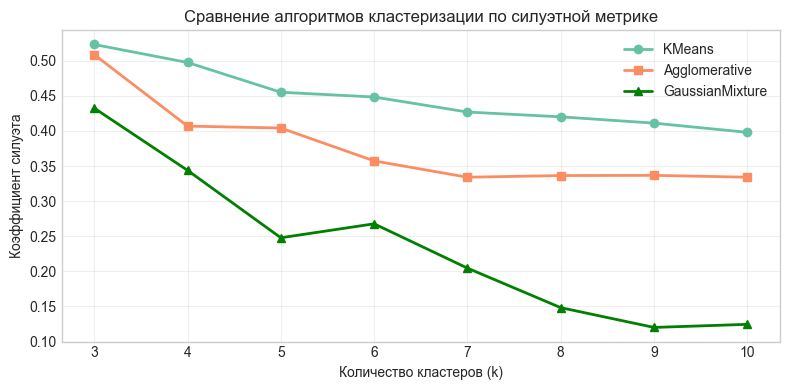

Лучшие результаты по методам:
KMeans:            k = 3, silhouette = 0.5231
Agglomerative:     k = 3, silhouette = 0.5087
GaussianMixture:   k = 3, silhouette = 0.4324

Оптимальный алгоритм: KMeans (k = 3) с силуэтом 0.5231


In [71]:
# Диапазон кластеров для перебора
k_range = range(3, 11)

# Списки для хранения результатов силуэта
kmeans_scores = []
agg_scores = []
gmm_scores = []

# 1. Тестируем KMeans
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    kmeans_scores.append(score)

# 2. Тестируем Agglomerative
for k in k_range:
    model = AgglomerativeClustering(n_clusters=k)
    labels = model.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    agg_scores.append(score)

# 3. Тестируем GaussianMixture
for k in k_range:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(X_transformed)
    score = silhouette_score(X_transformed, labels)
    gmm_scores.append(score)

# Визуализация сравнения трех алгоритмов
plt.figure(figsize=(8, 4))
plt.plot(k_range, kmeans_scores, 'o-', linewidth=2, color=colors[0], label='KMeans')
plt.plot(k_range, agg_scores, 's-', linewidth=2, color=colors[1], label='Agglomerative')
plt.plot(k_range, gmm_scores, '^-', linewidth=2, color='green', label='GaussianMixture')

plt.xlabel('Количество кластеров (k)')
plt.ylabel('Коэффициент силуэта')
plt.title('Сравнение алгоритмов кластеризации по силуэтной метрике')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Находим лучшие параметры для каждого метода
best_k_km = k_range[np.argmax(kmeans_scores)]
best_k_agg = k_range[np.argmax(agg_scores)]
best_k_gmm = k_range[np.argmax(gmm_scores)]

print("Лучшие результаты по методам:")
print(f"KMeans:            k = {best_k_km}, silhouette = {max(kmeans_scores):.4f}")
print(f"Agglomerative:     k = {best_k_agg}, silhouette = {max(agg_scores):.4f}")
print(f"GaussianMixture:   k = {best_k_gmm}, silhouette = {max(gmm_scores):.4f}")

# Выбираем лучший алгоритм
all_scores = [max(kmeans_scores), max(agg_scores), max(gmm_scores)]
all_methods = ['KMeans', 'Agglomerative', 'GaussianMixture']
all_k = [best_k_km, best_k_agg, best_k_gmm]
best_idx = np.argmax(all_scores)

print(f"\nОптимальный алгоритм: {all_methods[best_idx]} (k = {all_k[best_idx]}) с силуэтом {all_scores[best_idx]:.4f}")

In [72]:
# Обучаем KMeans с k=3
best_model = KMeans(n_clusters=best_k_km, random_state=42, n_init=10)
rfm_table_clean['Cluster'] = best_model.fit_predict(X_transformed)

# Распределение клиентов по кластерам
cluster_distribution = pd.DataFrame({
    'Количество клиентов': rfm_table_clean['Cluster'].value_counts(),
    'Доля (%)': rfm_table_clean['Cluster'].value_counts(normalize=True).mul(100).round(1)
}).sort_index()

print("Распределение клиентов по кластерам:")
display(cluster_distribution)

Распределение клиентов по кластерам:


,Количество клиентов,Доля (%)
Cluster,,
0,1001,24.8
1,2262,56.1
2,772,19.1


**Вывод.** Сравнение трех различных алгоритмов по коэффициенту силуэта показало, что наилучшее качество разделения обеспечивает метод KMeans при разбиении на три группы. Самым крупным сегментом клиентской базы стал кластер 1, который объединил более половины всех покупателей (56.1%), в то время как на кластеры 0 и 2 пришлось 24,8% и 19,1% соответственно.

### 3.2. Интерпретация результатов кластеризации

Перейдём к интерпретации полученных кластеров.

#### 3.2.1. Визуализация кластеров

Визуализируйте результаты в виде 3D-диаграммы с осями Recency, Frequency и Monetary. Проанализируйте полученную диаграмму и попробуйте понять, какие кластеры у вас получились.

In [73]:
# Создаём 3D-диаграмму
rfm_table_clean['Cluster_Str'] = rfm_table_clean['Cluster'].astype(str)
fig_2 = px.scatter_3d(
    rfm_table_clean, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Cluster_Str',
    title='3D-визуализация кластеров',
    labels={'Recency': 'Давность (дней)', 
            'Frequency': 'Частота (заказов)', 
            'Monetary': 'Сумма (фунты)',
            'Cluster_Str': 'Кластер'},
    opacity=0.7
)

fig_2.update_layout(
    height=500,
    width=600,
    title={
        'text': '3D-визуализация кластеров',
        'x': 0.4,
        'xanchor': 'center',
        'y': 0.88,
        'yanchor': 'top'
    },
    margin=dict(l=0, r=0, b=0, t=50), 
    legend=dict(title='Кластеры')
)

fig_2.update_traces(marker=dict(size=3))
#fig_2.show()
#fig_2.write_html("data/html/fig_2.html")
plt.close()

<div align="center"><img src = 'data/image/fig_2.png'></div>

Ознакомится с интеративным графиком можно по [ссылке](https://htmlpreview.github.io/?https://github.com/emozdir/Projects/blob/master/projects/project_6/data/html/fig_2.html)

**Вывод.** Трёхмерная визуализация в исходных осях RFM подтверждает высокое качество разделения клиентов. Алгоритм KMeans безошибочно выделил плотное основание из розничных покупателей у нулевых отметок (кластер 1), изолировал «уходящих» клиентов в вытянутый шлейф по оси давности (кластер 0) и поднял наиболее ценных VIP-закупщиков на верхние ярусы по оси денежной ценности (кластер 2). Отсутствие хаотично перемешанных точек доказывает физическую устойчивость найденных сегментов.

In [ ]:
# Агрегируем медианные показатели RFM по кластерам
cluster_stats = rfm_table_clean.groupby('Cluster').agg({
    'CustomerID': 'count',
    'Recency': 'median',
    'Frequency': 'median',
    'Monetary': 'median'
}).rename(columns={'CustomerID': 'Покупателей'})

# Округляем денежные значения
cluster_stats['Monetary'] = cluster_stats['Monetary'].round(2)

print("Сводная статистика по кластерам (медианные значения):")
display(cluster_stats)

Сводная статистика по кластерам (медианные значения):


,Покупателей,Recency,Frequency,Monetary
Cluster,,,,
0,1001,248.0,1.0,294.12
1,2262,42.0,2.0,562.50
2,772,18.0,7.0,2502.04


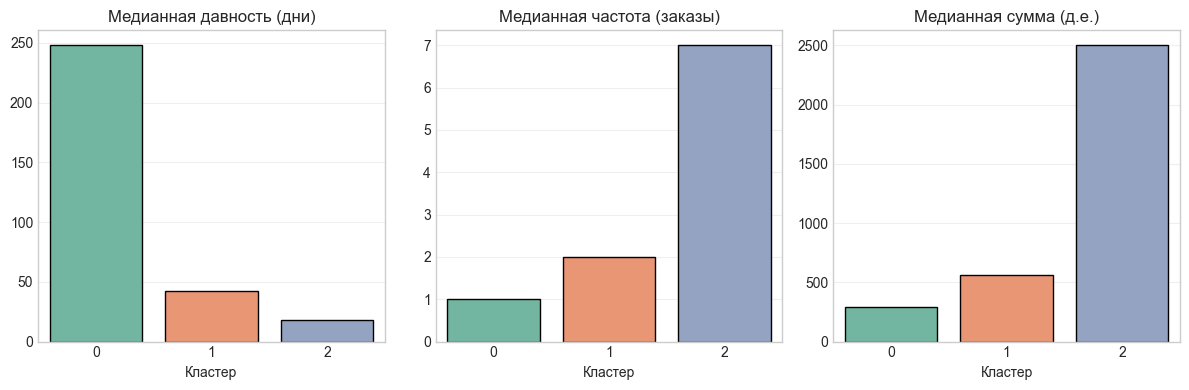

In [75]:
# Сбрасываем индекс
plot_data = cluster_stats.reset_index()

# Строим графики характеристик кластеров
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors_prof = sns.color_palette("Set2", 3)

# 1. График Recency (Давность)
sns.barplot(
    data=plot_data, x='Cluster', y='Recency', 
    palette=colors_prof, ax=axes[0]
)
axes[0].set_title('Медианная давность (дни)')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('')
axes[0].grid(True, alpha=0.3, axis='y')

# 2. График Frequency (Частота)
sns.barplot(
    data=plot_data, x='Cluster', y='Frequency', 
    palette=colors_prof, ax=axes[1]
)
axes[1].set_title('Медианная частота (заказы)')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('')
axes[1].grid(True, alpha=0.3, axis='y')

# 3. График Monetary (Сумма)
sns.barplot(
    data=plot_data, x='Cluster', y='Monetary', 
    palette=colors_prof, ax=axes[2]
)
axes[2].set_title('Медианная сумма (д.е.)')
axes[2].set_xlabel('Кластер')
axes[2].set_ylabel('')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show();

**Вывод.** Трёхмерная визуализация в исходных осях RFM и сводная статистика медианных значений подтверждают высокое качество разделения клиентов алгоритмом KMeans. Покупатели разделились на три однородные и геометрически изолированные группы с четкими экономическими различиями:
- Кластер 0 — Спящие клиенты (24.8% базы). Группа с критически высокой давностью покупки (медиана — 248 дней). Покупатели совершили всего один заказ с минимальным чеком (294.12 д.е.) и фактически перестали приносить доход компании. Данный сегмент требует проведения маркетинговых кампаний по реактивации.
- Кластер 1 — Постоянная розница (56.1% базы). Самая массовая и стабильная группа компании. Клиенты покупали относительно недавно (медиана — 42 дня), совершают в среднем по 2 заказа и приносят регулярный средний доход (562.50 д.е.), формируя устойчивую основу розничных продаж.
- Кластер 2 — VIP-клиенты и оптовики (19.1% базы). Наиболее ценная группа покупателей. Они демонстрируют максимальную свежесть (медиана — всего 18 дней назад) и высокую частоту повторных визитов (7 заказов), обеспечивая рекордный доход (2502.04 д.е.) и генерируя основной финансовый оборот магазина.

#### 3.2.2. Построение профиля кластеров

Далее составьте так называемый профиль кластеров. Для этого вам необходимо вернуться от декомпозированных данных (если вы производили понижение размерности) к RFM-таблице (очищенной от выбросов).

Сгруппируйте RFM-таблицу по полученным кластерам и рассчитайте среднее по каждому из признаков.

Чтобы результаты было проще интерпретировать, давайте познакомимся с одним из способов визуализации профиля кластеров — **Radar Chart** (полярная диаграмма, или диаграмма паутины). Это графическое представление значений нескольких эквивалентных категорий в форме паутины.

Radar Chart часто используется при определении профиля кластеров. На концах паутины откладываются оси, соответствующие признакам, описывающим объекты. На каждой из осей для каждого кластера откладываются средние значения соответствующих характеристик. Соединив точки по осям, мы получаем многоугольник. 

Пример полярной диаграммы для задачи кластеризации учеников по интересам:

<img src=https://www.datanovia.com/en/wp-content/uploads/2020/12/radar-chart-in-r-customized-fmstb-radar-chart-1.png width=500>

На этой диаграмме мы видим визуализацию признаков для одного из кластеров. Видно, что ученики, принадлежащие этому кластеру, в большей степени увлекаются музыкой (Music), а в меньшей — программированием (Programm).

В модуле `graph_objects` библиотеки `plotly` есть встроенная функция `Scatterpolar`, которая позволяет построить полярную диаграмму. На основе этой функции мы подготовили для вас функцию `plot_cluster_profile()`, которая позволяет визуализировать профиль каждого из кластеров в виде полярной диаграммы. У неё есть два параметра: `grouped_data` — сгруппированные по кластерам характеристики объектов (клиентов), `n_clusters` — количество кластеров.

Главное условие использования полярной диаграммы — все признаки должны быть приведены к единому масштабу с помощью нормализации, где 1 будет означать максимум, а 0 — минимум. Шаг с нормализацией мы также добавили в функцию `plot_cluster_profile()`.


In [76]:
def plot_cluster_profile(grouped_data, n_clusters):
    """Функция для визуализации профиля кластеров в виде полярной диаграммы.

    Args:
        grouped_data (DataFrame): таблица, сгруппированная по номерам кластеров с агрегированными характеристиками объектов.
        n_clusters (int): количество кластеров
    """
    # Нормализуем сгруппированные данные, приводя их к масштабу 0-1.
    scaler = MinMaxScaler()
    grouped_data = pd.DataFrame(scaler.fit_transform(grouped_data), columns=grouped_data.columns)
    # Создаём список признаков
    features = grouped_data.columns
    # Создаём пустую фигуру
    fig = go.Figure()
    # В цикле визуализируем полярную диаграмму для каждого кластера
    for i in range(n_clusters):
        # Создаём полярную диаграмму и добавляем её на общий график
        fig.add_trace(go.Scatterpolar(
            r=grouped_data.iloc[i].values, # радиусы
            theta=features, # название засечек
            fill='toself', # заливка многоугольника цветом
            name=f'Cluster {i}', # название — номер кластера
        ))
    # Обновляем параметры фигуры
    fig.update_layout(
        showlegend=True, # отображение легенды
        autosize=False, # устаналиваем свои размеры графика
        width=800, # ширина (в пикселях)
        height=800, # высота (в пикселях)
    )
    # Возвращаем фигуру
    return fig

Теперь у вас есть удобный инструмент для анализа профиля кластеров. Воспользуйтесь им, чтобы проинтерпретировать результаты, полученные на предыдущем шаге.

In [77]:
# У нас есть rfm_table_clean (очищенная от выбросов RFM-таблица)
# И есть предсказанные метки кластеров

# Добавляем метки кластеров в исходную RFM-таблицу
rfm_table_clean['Cluster'] = best_model.labels_

# Группируем исходную RFM-таблицу
cluster_profile = rfm_table_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Вызываем функцию
fig_3 = plot_cluster_profile(cluster_profile, n_clusters=3)
fig_3.update_layout(title="Профиль кластеров", title_x=0.5)
#fig_3.show()
#fig_3.write_html("data/html/fig_3.html")
plt.close()

<div align="center"><img src = 'data/image/fig_3.png' width="600"></div>

Ознакомится с интерактивным графиком можно по [ссылке](https://htmlpreview.github.io/?https://github.com/emozdir/Projects/blob/master/projects/project_6/data/html/fig_3.html)

**Вывод**: Полярная диаграмма (Radar Chart) наглядно визуализирует профили полученных сегментов в нормализованном масштабе, позволяя дать каждому кластеру чёткую интерпретацию:
- Кластер 0 — Спящие клиенты. На графике данный сегмент представлен синей линией, уходящей в абсолютный максимум по оси Recency (1.0) при нулевых показателях частоты и денег. Это покупатели, которые совершили один-два случайных заказа и давно перестали коммуницировать с магазином.
- Кластер 1 — Разовые и новые клиенты. Оранжевый треугольник сосредоточен ближе к центру осей. Покупатели обладают хорошей свежестью заказов, но пока имеют минимальную частоту покупок и низкий средний чек. Это перспективная группа для дальнейшего развития лояльности.
- Кластер 2 — VIP-клиенты. Зелёный многоугольник занимает максимальную площадь, забирая пиковые значения (1.0) по осям Frequency (частота) и Monetary (выручка) при околонулевой давности. Это ключевой сегмент высокодоходных постоянных клиентов и оптовиков, генерирующих основную прибыль бизнеса.

## 5. Выводы и оформление работы

**Сегментация клиентов интернет-магазина**

Успешно реализован проект по сегментации клиентов интернет-магазина подарков по их активности. Работа выполнена полностью: от очистки сырых данных и первичного анализа до создания новых признаков и кластеризации методами машинного обучения.

**Преимущества созданных признаков (Feature Engineering)**

Вместо стандартного подхода классический RFM-анализ был расширен 9 дополнительными признаками. Полезность каждого из них подтверждена статистическими тестами (критерии Манна-Уитни, Краскела-Уоллиса и корреляция Спирмена):

- **Временные особенности спроса**: учтены суточные циклы покупок (`TimeOfDay`), поведение покупателей в выходные (`IsSunday`) и всплеск продаж в «Черную пятницу» (`IsNovember`). Это помогло защитить модель от дублирования информации.
- **Географические различия**: выделены домашний рынок компании (`IsUK`) и крупные европейские оптовые узлы (`HighCheckCountry`, `IsPurePeak`).
- **Оценка рисков**: с помощью метода межквартильного размаха (IQR) определены границы аномально больших корзин (от 57 товаров — `IsLargeBasket`) и проблемных клиентов с частыми отменами (от 27 штук — `IsRiskUser`). Также подтверждена связь между высокой ценой товара и вероятностью его возврата (`IsHighReturnRisk`).

**Результаты сегментации:**
На основе подготовленных признаков и алгоритма KMeans вся клиентская база была разделена на три устойчивые группы:

- **Кластер 1** — Постоянная розница (56.1% базы). Самая массовая и стабильная группа клиентов. Покупают регулярно (медиана давности — 42 дня), делают обычно по 2 заказа и приносят устойчивый средний доход (562.50 д.е.). 

    Они приносят компании основную часть розничной выручки.
    
    **Рекомендация**: Поддерживать их интерес через обычные рассылки, подборки популярных товаров и стандартные розничные акции.
   
- **Кластер 0** — Спящие / Уходящие клиенты (24.8% базы). Клиенты, которые очень долго ничего не покупали (медиана — 248 дней, то есть почти 8 месяцев затишья). Они сделали всего по 1 заказу с минимальным чеком (294.12 д.е.) и больше не возвращались.

    **Рекомендация**: Попробовать вернуть этих клиентов с помощью скидок, напоминающих писем или специальных промокодов.
   
- **Кластер 2** — VIP-клиенты и мелкий опт (19.1% базы). Самая ценная группа, которая приносит больше всего денег. Покупали совсем недавно (медиана — всего 18 дней назад), часто возвращаются (по 7 заказов) и делают заказы на крупные суммы (медиана — 2502.04 д.е.).

    **Рекомендация**: Предложить им особые условия: выделить менеджера для связи, дать доступ к оптовым ценам, показывать новинки раньше остальных и давать накопительные скидки.

Итоговая структура данных и метки кластеров полностью готовы к загрузке в CRM-систему магазина для автоматической настройки работы с клиентами.